In [1]:
from dataclasses import replace, dataclass
from typing import List, Tuple
import pandas as pd
from typing import Literal, Optional 
import pandas as pd 

from src.dataloading.epidataorchestration import EpiConfig, EpiDataOrchestrator

Entire regimen we've been studying is:

min_date        = '2011-06-01'
max_date        = '2020-06-01'
split_trainval  = '2018-06-01'
split_valtest   = '2019-06-01'

Fixed origin expanding window:
splits = [
    ('2011-06-01', '2014-06-01', '2015-06-01', '2016-06-01'),
    ('2011-06-01', '2015-06-01', '2016-06-01', '2017-06-01'),
    ('2011-06-01', '2016-06-01', '2017-06-01', '2018-06-01'),
    ('2011-06-01', '2017-06-01', '2018-06-01', '2019-06-01'),
    ('2011-06-01', '2018-06-01', '2019-06-01', '2020-06-01'),
]

Expanding window:
splits = [
    ('2011-06-01', '2014-06-01', '2015-06-01', '2016-06-01'),
    ('2012-06-01', '2015-06-01', '2016-06-01', '2017-06-01'),
    ('2013-06-01', '2016-06-01', '2017-06-01', '2018-06-01'),
    ('2014-06-01', '2017-06-01', '2018-06-01', '2019-06-01'),
    ('2015-06-01', '2018-06-01', '2019-06-01', '2020-06-01'),
]

In [2]:
from dataclasses import dataclass, field
from typing import Literal
import pandas as pd


@dataclass
class CrossValidationEpiConfig:
    """
    Cross-validation configuration for epidemic forecasting.

    Supports both yearly splits (influenza) and monthly splits (COVID daily),
    controlled by the `unit` parameter.

    Parameters
    ----------
    min_date, max_date : str
        Full date range available for cross-validation.
    num_folds : int
        Number of folds to generate.
    train_periods : int
        Length of training window in `unit` units.
    val_periods : int
        Length of validation window in `unit` units.
    test_periods : int
        Length of test window in `unit` units.
    method : Literal['fixed_origin', 'rolling_window']
        fixed_origin: training always starts at min_date, grows each fold.
        rolling_window: training window slides forward each fold.
    unit : Literal['years', 'months']
        Temporal unit for all period lengths and rolling offsets.
        Use 'years' for influenza (weekly data).
        Use 'months' for COVID (daily data).

    Examples
    --------
    # Influenza — yearly (existing behaviour unchanged)
    cfg = CrossValidationEpiConfig(
        min_date='2011-06-01', max_date='2020-06-01',
        num_folds=5, train_periods=3, val_periods=1, test_periods=1,
        method='rolling_window', unit='years'
    )

    # COVID — monthly
    cfg = CrossValidationEpiConfig(
        min_date='2020-03-02', max_date='2023-01-01',
        num_folds=5, train_periods=12, val_periods=3, test_periods=3,
        method='rolling_window', unit='months'
    )
    """

    min_date        : str
    max_date        : str
    num_folds       : int
    train_periods   : int
    val_periods     : int
    test_periods    : int
    method          : Literal['fixed_origin', 'rolling_window']
    unit            : Literal['years', 'months'] = 'years'

    splits_         : dict = field(default_factory=dict, init=False, repr=False)

    def __post_init__(self):
        self._validate()
        self._set_splits()

    # ------------------------------------------------------------------
    # Internal helpers
    # ------------------------------------------------------------------

    def _offset(self, n: int) -> pd.DateOffset:
        """Return a DateOffset of n units."""
        if self.unit == 'years':
            return pd.DateOffset(years=n)
        else:
            return pd.DateOffset(months=n)

    # ------------------------------------------------------------------
    # Validation
    # ------------------------------------------------------------------

    def _validate(self):
        min_dt = pd.Timestamp(self.min_date)
        max_dt = pd.Timestamp(self.max_date)

        # Check a single fold fits within the date range
        single_fold_end = (
            min_dt
            + self._offset(self.train_periods)
            + self._offset(self.val_periods)
            + self._offset(self.test_periods)
        )
        if single_fold_end > max_dt:
            raise ValueError(
                f"Date range {self.min_date} to {self.max_date} is too short "
                f"for train/val/test = "
                f"{self.train_periods}/{self.val_periods}/{self.test_periods} {self.unit}."
            )

        if self.method == 'fixed_origin':
            # Train window grows by 1 unit per fold
            last_test_end = (
                min_dt
                + self._offset(self.train_periods + self.num_folds - 1)
                + self._offset(self.val_periods)
                + self._offset(self.test_periods)
            )
        elif self.method == 'rolling_window':
            # Entire window slides forward by 1 unit per fold
            last_test_end = (
                min_dt
                + self._offset(self.num_folds - 1)
                + self._offset(self.train_periods)
                + self._offset(self.val_periods)
                + self._offset(self.test_periods)
            )
        else:
            raise ValueError(f'{self.method} is not a valid method')

        if last_test_end > max_dt:
            raise ValueError(
                f"{self.num_folds} folds with these window sizes exceed the available "
                f"date range. Last fold would end {last_test_end.date()}, "
                f"but max_date is {self.max_date}."
            )

    # ------------------------------------------------------------------
    # Split generation
    # ------------------------------------------------------------------

    def _set_splits(self):
        min_dt = pd.Timestamp(self.min_date)
        max_dt = pd.Timestamp(self.max_date)

        for fold_idx in range(self.num_folds):

            if self.method == 'fixed_origin':
                train_start = min_dt
                train_end   = min_dt + self._offset(self.train_periods + fold_idx)

            elif self.method == 'rolling_window':
                train_start = min_dt + self._offset(fold_idx)
                train_end   = train_start + self._offset(self.train_periods)

            else:
                raise ValueError('invalid method')

            fold_min_date       = train_start
            fold_trainval_split = train_end
            fold_valtest_split  = train_end + self._offset(self.val_periods)
            fold_max_date       = fold_valtest_split + self._offset(self.test_periods)

            if fold_max_date > max_dt:
                raise ValueError(
                    f"Fold {fold_idx} exceeds max_date. Reduce num_folds."
                )

            self.splits_[fold_idx] = {
                'min_date'       : fold_min_date.strftime('%Y-%m-%d'),
                'trainval_split' : fold_trainval_split.strftime('%Y-%m-%d'),
                'valtest_split'  : fold_valtest_split.strftime('%Y-%m-%d'),
                'max_date'       : fold_max_date.strftime('%Y-%m-%d'),
            }

    # ------------------------------------------------------------------
    # Summary
    # ------------------------------------------------------------------

    def summary(self):
        unit_label = self.unit[0]   # 'y' or 'm'
        print(
            f"\nCV Config — method: {self.method}, unit: {self.unit}, "
            f"folds: {self.num_folds}, "
            f"train/val/test: {self.train_periods}{unit_label}/"
            f"{self.val_periods}{unit_label}/{self.test_periods}{unit_label}\n"
        )
        header = (
            f"{'Fold':<6} {'Min Date':<14} {'Train/Val':<14} "
            f"{'Val/Test':<14} {'Max Date':<14}"
        )
        print(header)
        print("-" * len(header))
        for fold_idx, s in self.splits_.items():
            print(
                f"{fold_idx:<6} {s['min_date']:<14} {s['trainval_split']:<14} "
                f"{s['valtest_split']:<14} {s['max_date']:<14}"
            )

In [99]:
cfg = CrossValidationEpiConfig(
    min_date        = '2021-06-01',
    max_date        = '2023-01-01',
    num_folds       = 5,
    train_periods   = 9,   # 12 months training
    val_periods     = 3,    # 3 months val
    test_periods    = 3,    # 3 months test
    method          = 'rolling_window',
    unit            = 'months'
)
cfg.summary()


CV Config — method: rolling_window, unit: months, folds: 5, train/val/test: 9m/3m/3m

Fold   Min Date       Train/Val      Val/Test       Max Date      
------------------------------------------------------------------
0      2021-06-01     2022-03-01     2022-06-01     2022-09-01    
1      2021-07-01     2022-04-01     2022-07-01     2022-10-01    
2      2021-08-01     2022-05-01     2022-08-01     2022-11-01    
3      2021-09-01     2022-06-01     2022-09-01     2022-12-01    
4      2021-10-01     2022-07-01     2022-10-01     2023-01-01    


In [30]:
cfg.splits_.items()

dict_items([(0, {'min_date': '2020-06-01', 'trainval_split': '2021-06-01', 'valtest_split': '2021-11-01', 'max_date': '2022-04-01'}), (1, {'min_date': '2020-07-01', 'trainval_split': '2021-07-01', 'valtest_split': '2021-12-01', 'max_date': '2022-05-01'}), (2, {'min_date': '2020-08-01', 'trainval_split': '2021-08-01', 'valtest_split': '2022-01-01', 'max_date': '2022-06-01'}), (3, {'min_date': '2020-09-01', 'trainval_split': '2021-09-01', 'valtest_split': '2022-02-01', 'max_date': '2022-07-01'}), (4, {'min_date': '2020-10-01', 'trainval_split': '2021-10-01', 'valtest_split': '2022-03-01', 'max_date': '2022-08-01'}), (5, {'min_date': '2020-11-01', 'trainval_split': '2021-11-01', 'valtest_split': '2022-04-01', 'max_date': '2022-09-01'}), (6, {'min_date': '2020-12-01', 'trainval_split': '2021-12-01', 'valtest_split': '2022-05-01', 'max_date': '2022-10-01'}), (7, {'min_date': '2021-01-01', 'trainval_split': '2022-01-01', 'valtest_split': '2022-06-01', 'max_date': '2022-11-01'}), (8, {'min_da

In [100]:
from src.utils import get_data_env
from src.dataloading import EpiConfig, EpiDataOrchestrator

from src.dataloading import BaseLineDataLoaderManager
from src.models import PersistenceModel, ClimateologyModel, ConstantModel, ClimaScaleModel

@dataclass
class EpiFold:

    foldconfig:             EpiConfig 
    foldepidataorchestrator:EpiDataOrchestrator 


@dataclass
class FoldCollection:

    epifolds: List[EpiFold]
    foldconfig: CrossValidationEpiConfig
    

    def __iter__(self):
        return iter(self.epifolds)
    
    def __len__(self):
        return len(self.epifolds)

    def __getitem__(self, idx: int) -> EpiFold:
        return self.epifolds[idx]

In [101]:
# get data
disease_name    = 'covid_daily'
nuts_level      = 'nuts3'
split_berlin    = False

horizon_size    = 1
horizon_leadtime= 7
sequence_length = 7
lag_num         = 1

epifolds = []

for fold, fold_dates in cfg.splits_.items():

    config = EpiConfig(
        disease             = disease_name,
        min_date            = fold_dates['min_date'], 
        max_date            = fold_dates['max_date'],
        horizon_size        = horizon_size,
        sequence_length     = sequence_length,
        horizon_leadtime    = horizon_leadtime,
        lag_num             = lag_num,
        nuts_level          = nuts_level,
        log_transform       = ['incidence'],
        split_berlin        = split_berlin,
        split_trainval      = fold_dates['trainval_split'], 
        split_valtest       = fold_dates['valtest_split'],
        target_column       = 'incidence',
        lag_column          = 'incidence',  
        verbose             = 0  ,

        temporal_frequency  = 'd',
        time_index_w        = False,
        time_index_d        = True,

        feature_popage          = True,
        feature_population_size =True,
        feature_gisd            = False,
        feature_popdens         = True
        )    

    data_orchestrator = (EpiDataOrchestrator(config).build())

    epifolds.append(EpiFold(config, data_orchestrator))

foldcollection = FoldCollection(epifolds, cfg)


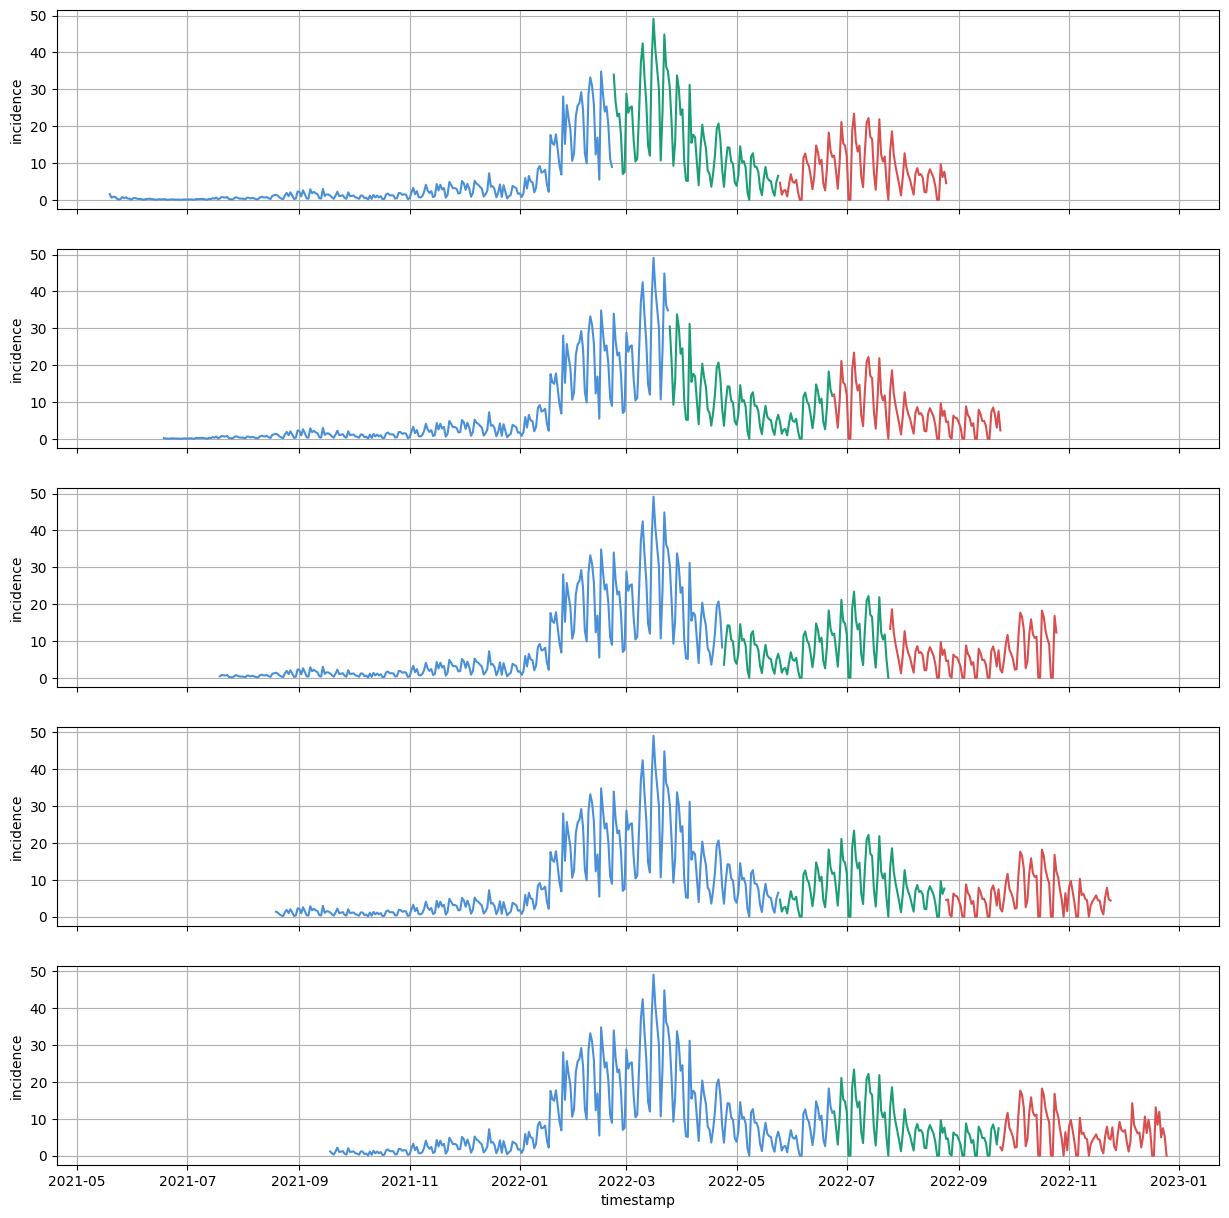

In [102]:
node = 26

fig, axes = plt.subplots(5,1,figsize = (15,15), sharex=True)
axes      = axes.flatten()

for fold_idx, epifold in enumerate(foldcollection.epifolds):

    df      = epifold.foldepidataorchestrator.data_final.data_denorm
    df_node = df[df['nuts_node'] == node]

    sns.lineplot(df_node[df_node['train']], x = 'timestamp', y = 'incidence_lag0', color = traincolor, ax = axes[fold_idx])
    sns.lineplot(df_node[df_node['val']],   x = 'timestamp', y = 'incidence_lag0', color = valcolor, ax = axes[fold_idx])
    sns.lineplot(df_node[df_node['test']],  x = 'timestamp', y = 'incidence_lag0', color = testcolor, ax = axes[fold_idx])

    axes[fold_idx].grid()
    axes[fold_idx].set_ylabel('incidence')


In [39]:
foldcollection.epifolds[5].foldepidataorchestrator.data_final.data['timestamp'].max()

Timestamp('2021-12-24 00:00:00')

In [ ]:
models = {}

for fold_idx, fold in enumerate(foldcollection):

    baseline_data            = BaseLineDataLoaderManager(fold.foldepidataorchestrator)
    
    constant_predictor      = ConstantModel(baseline_data,name      = f'fold{fold_idx+1}')
    persistence_predictor   = PersistenceModel(baseline_data,name   = f'fold{fold_idx+1}')
    climateology            = ClimateologyModel(baseline_data,name  = f'fold{fold_idx+1}')
    climascale              = ClimaScaleModel(baseline_data,name    = f'fold{fold_idx+1}')

    constant_predictor.set_model_hparams(0)
    constant_predictor.forecast('test')
    persistence_predictor.forecast('test')
    climateology.forecast('test')
    climascale.forecast('test')

    models_fold = [persistence_predictor,climateology]
    models[f'fold{fold_idx+1}'] = models_fold

0
1
2
3
4
5
6
7
8
9


In [46]:
# model_evaluations_foldwise 
from src.evaluation import Evaluator

persistences    = []
climateologies  = []


for fold_idx, fold in enumerate(foldcollection):
    for model_idx, model in enumerate(models[f'fold{fold_idx + 1}']):
        if model.__class__.__name__ == 'PersistenceModel':
            persistences.append(model)
        if model.__class__.__name__ == 'ClimateologyModel':
            climateologies.append(model)


evaluators = {
    'persistence':  Evaluator(persistences).add_evaluation(),
    'climateology': Evaluator(climateologies).add_evaluation()
}

figure_raw1 = (evaluators['persistence'].plotter.plot_metric_compilation(metrics = ['ccc','r2'])
            .change_figsize(14,5)
            .layout.set_ylim([-1,1], ax = 1)
            .labels.change_suptitle(f'persistence', fontweight='bold', fontsize=14)
            )



figure_raw2 = (evaluators['climateology'].plotter.plot_metric_compilation(metrics = ['ccc','r2'])
            .change_figsize(14,5)
            .layout.set_ylim([-1,1], ax = 1)
            .labels.change_suptitle(f'persistence', fontweight='bold', fontsize=14)
            )


computing metrics: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 9/9 [00:13<00:00,  1.54s/it]
/scratch/de-schrijvers/projects/infectious_disease_gnn/src/evaluation/evaluationplotter.py:215: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='center', fontsize=8)
/scratch/de-schrijvers/projects/infectious_disease_gnn/src/evaluation/evaluationplotter.py:215: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='center', fontsize=8)
/scratch/de-schrijvers/projects/infectious_disease_gnn/src/evaluation/evaluationplotter.py:215: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. af

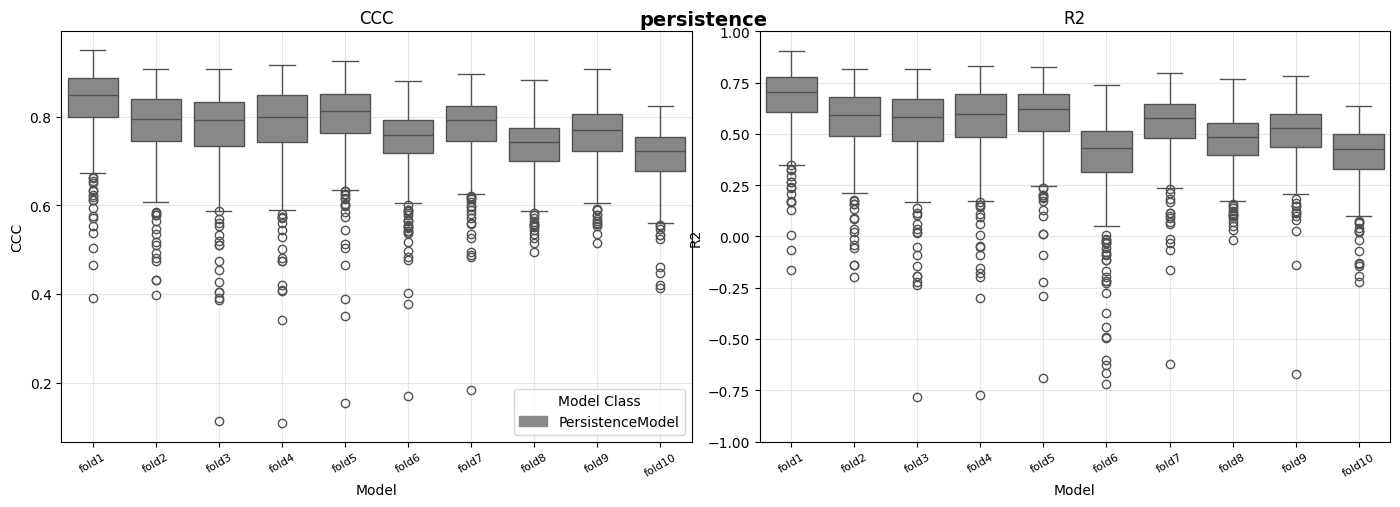

In [48]:
figure_raw1.show()


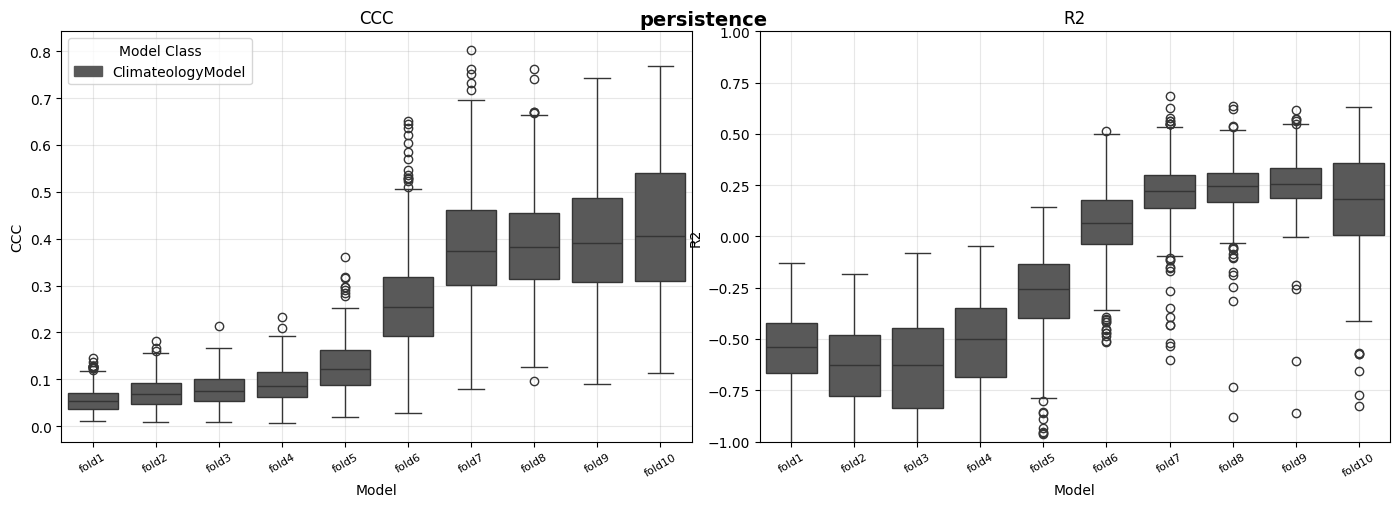

In [49]:
figure_raw2.show()


==                     ig_1                     ==
model_hparams_set ✓
global_hparams_set ✓
Dataloader Snapshot: GraphData(x=(400, 22, 7), y=(400, 1), edge_index=(2, 400), edge_weight=(400,))
Epoch 001 train loss: 0.3036, val loss: 0.4004 ✓ (new best)
Epoch 002 train loss: 0.2829, val loss: 0.4096 (patience: 1/10)
Epoch 003 train loss: 0.2714, val loss: 0.4190 (patience: 2/10)
Epoch 004 train loss: 0.2734, val loss: 0.3836 ✓ (new best)
Epoch 005 train loss: 0.2662, val loss: 0.3957 (patience: 1/10)
Epoch 006 train loss: 0.2718, val loss: 0.3949 (patience: 2/10)
Epoch 007 train loss: 0.2676, val loss: 0.4127 (patience: 3/10)
Epoch 008 train loss: 0.2716, val loss: 0.3858 (patience: 4/10)
Epoch 009 train loss: 0.2730, val loss: 0.4129 (patience: 5/10)
Epoch 010 train loss: 0.2695, val loss: 0.3897 (patience: 6/10)
lr has been updated from 5.00e-03 to 2.50e-03
Epoch 011 train loss: 0.2870, val loss: 0.3060 ✓ (new best)
Epoch 012 train loss: 0.2892, val loss: 0.3147 (patience: 1/10)
Epoch

/scratch/de-schrijvers/projects/infectious_disease_gnn/src/models/deep/deepmodel.py:241: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


Early stopping: Validation loss hasn't improved for 10 epochs
Restored model from best validation loss: 0.2622
trained ✓


Forecasting test: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 152/152 [00:00<00:00, 191.02it/s]


Test loss: 3.7596
forecasted ✓

==                     gm_1                     ==
model_hparams_set ✓
global_hparams_set ✓
Dataloader Snapshot: GraphData(x=(400, 22, 7), y=(400, 1), edge_index=(2, 2488), edge_weight=(2488,))
Epoch 001 train loss: 0.3156, val loss: 0.3945 ✓ (new best)
Epoch 002 train loss: 0.2833, val loss: 0.3909 ✓ (new best)
Epoch 003 train loss: 0.2827, val loss: 0.3701 ✓ (new best)
Epoch 004 train loss: 0.2764, val loss: 0.3757 (patience: 1/10)
Epoch 005 train loss: 0.2710, val loss: 0.3685 ✓ (new best)
Epoch 006 train loss: 0.2737, val loss: 0.3829 (patience: 1/10)
Epoch 007 train loss: 0.2752, val loss: 0.3966 (patience: 2/10)
Epoch 008 train loss: 0.2740, val loss: 0.4068 (patience: 3/10)
Epoch 009 train loss: 0.2751, val loss: 0.4327 (patience: 4/10)
Epoch 010 train loss: 0.2748, val loss: 0.4064 (patience: 5/10)
Epoch 011 train loss: 0.2771, val loss: 0.4060 (patience: 6/10)
lr has been updated from 5.00e-03 to 2.50e-03
Epoch 012 train loss: 0.2778, val loss: 

...

Test loss: 0.5711
forecasted ✓

==                    cm_10                     ==
model_hparams_set ✓
global_hparams_set ✓
Dataloader Snapshot: GraphData(x=(400, 22, 7), y=(400, 1), edge_index=(2, 3905), edge_weight=(3905,))
Epoch 001 train loss: 0.1914, val loss: 0.4877 ✓ (new best)
Epoch 002 train loss: 0.1632, val loss: 0.4972 (patience: 1/10)
Epoch 003 train loss: 0.1431, val loss: 0.4773 ✓ (new best)
Epoch 004 train loss: 0.1401, val loss: 0.4600 ✓ (new best)
Epoch 005 train loss: 0.1369, val loss: 0.4681 (patience: 1/10)
Epoch 006 train loss: 0.1370, val loss: 0.4606 (patience: 2/10)
Epoch 007 train loss: 0.1359, val loss: 0.4881 (patience: 3/10)
Epoch 008 train loss: 0.1359, val loss: 0.4669 (patience: 4/10)
Epoch 009 train loss: 0.1360, val loss: 0.4771 (patience: 5/10)
Epoch 010 train loss: 0.1369, val loss: 0.4867 (patience: 6/10)
lr has been updated from 5.00e-03 to 2.50e-03
Epoch 011 train loss: 0.1451, val loss: 0.5180 (patience: 7/10)
Epoch 012 train loss: 0.1435, val lo

/scratch/de-schrijvers/projects/infectious_disease_gnn/src/models/deep/deepmodel.py:241: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


Early stopping: Validation loss hasn't improved for 10 epochs
Restored model from best validation loss: 0.4600
trained ✓


Forecasting test: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 154/154 [00:00<00:00, 191.18it/s]


Test loss: 0.5965
forecasted ✓


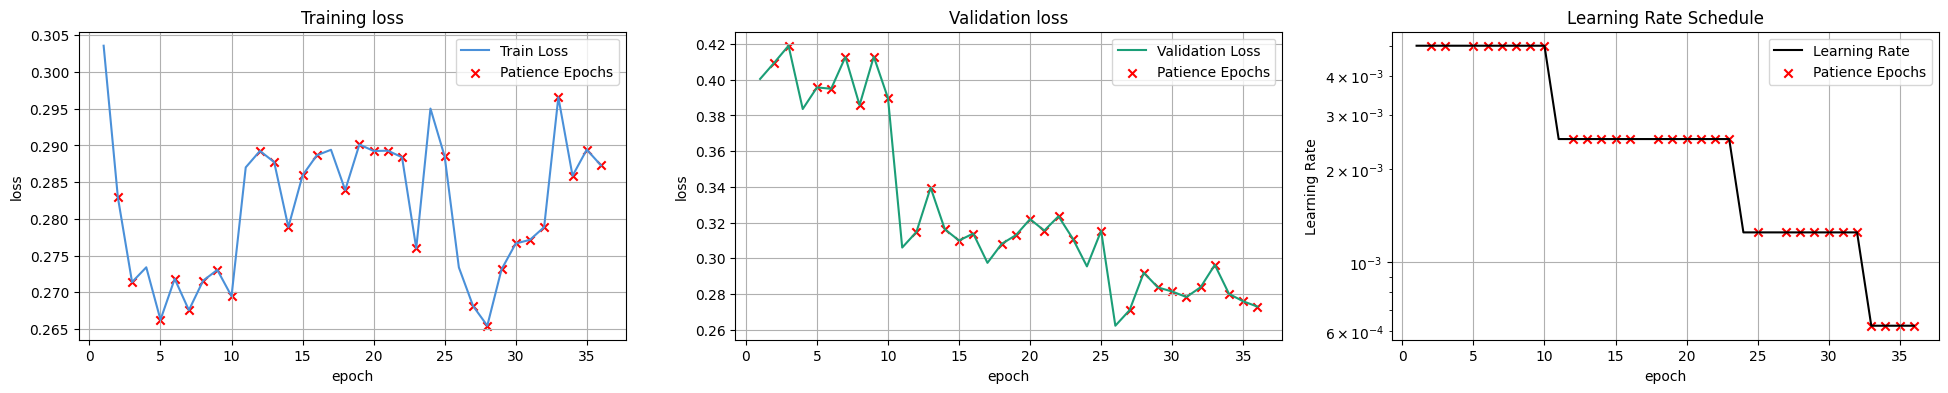

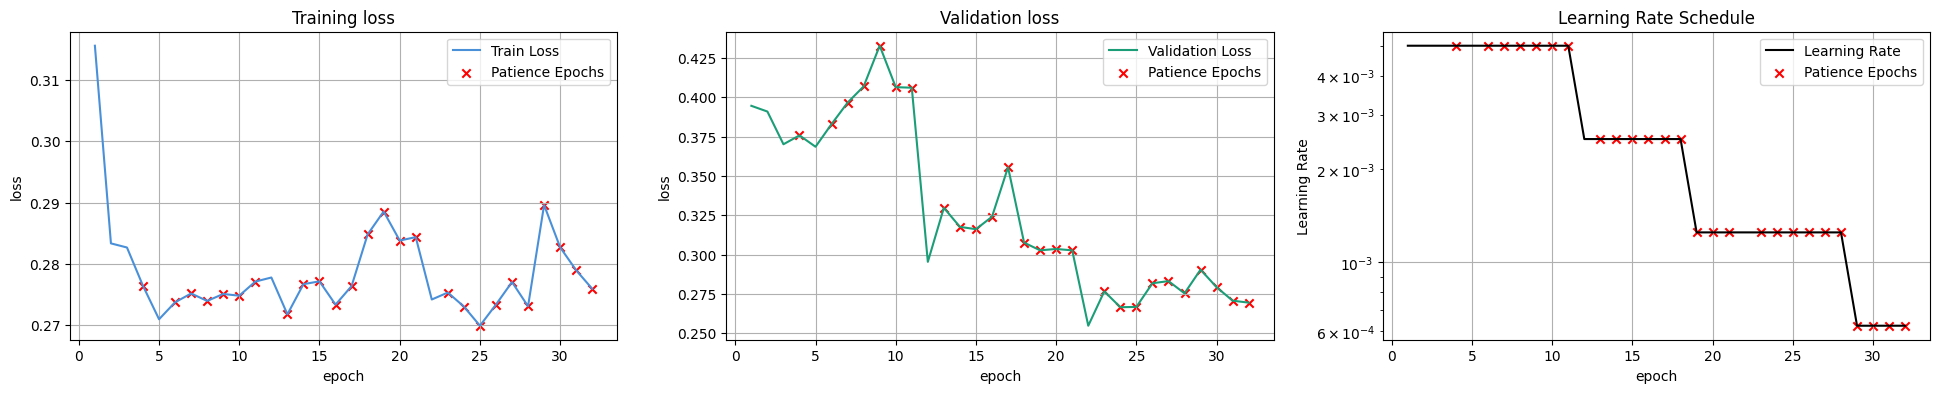

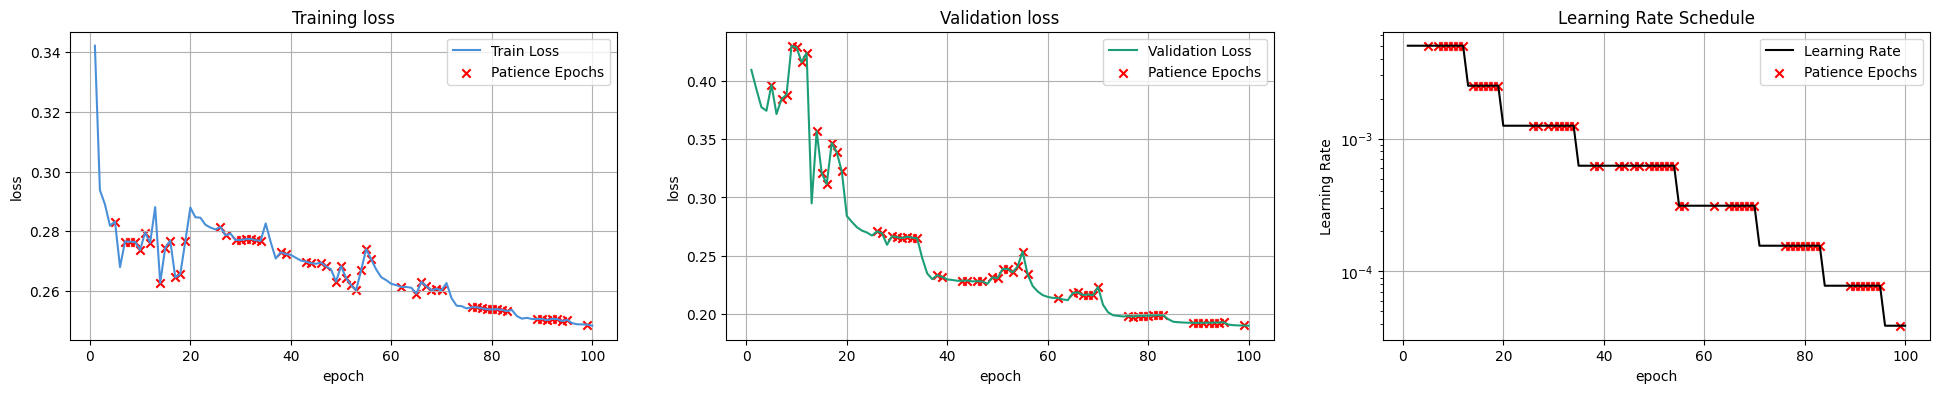

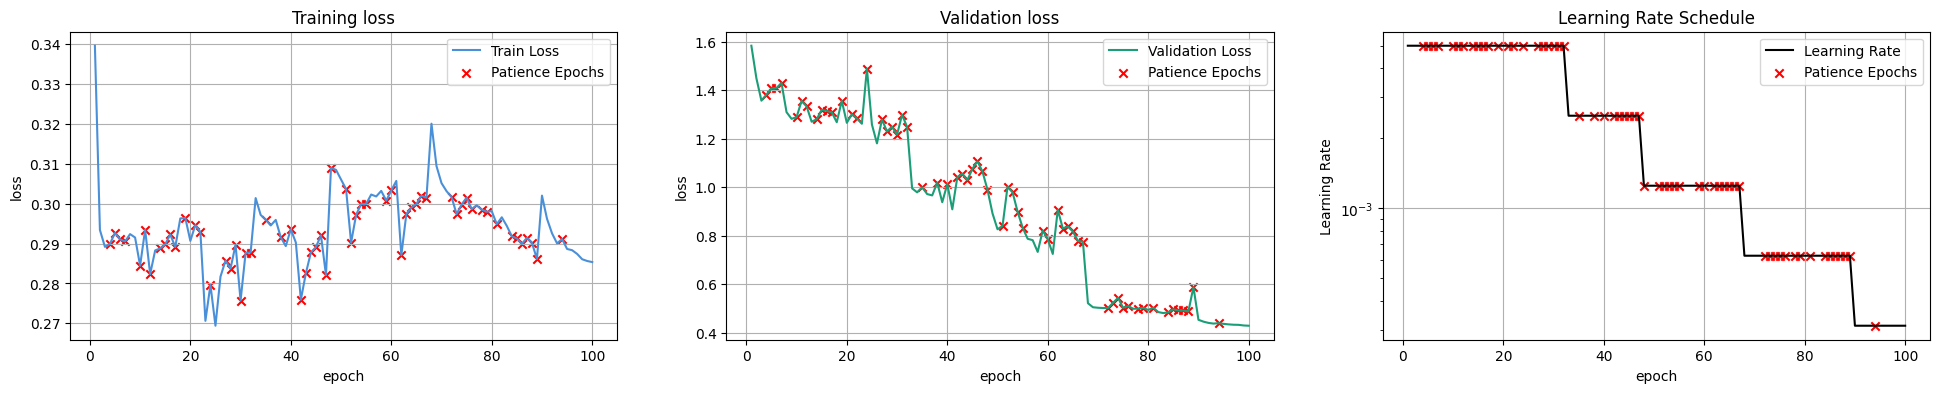

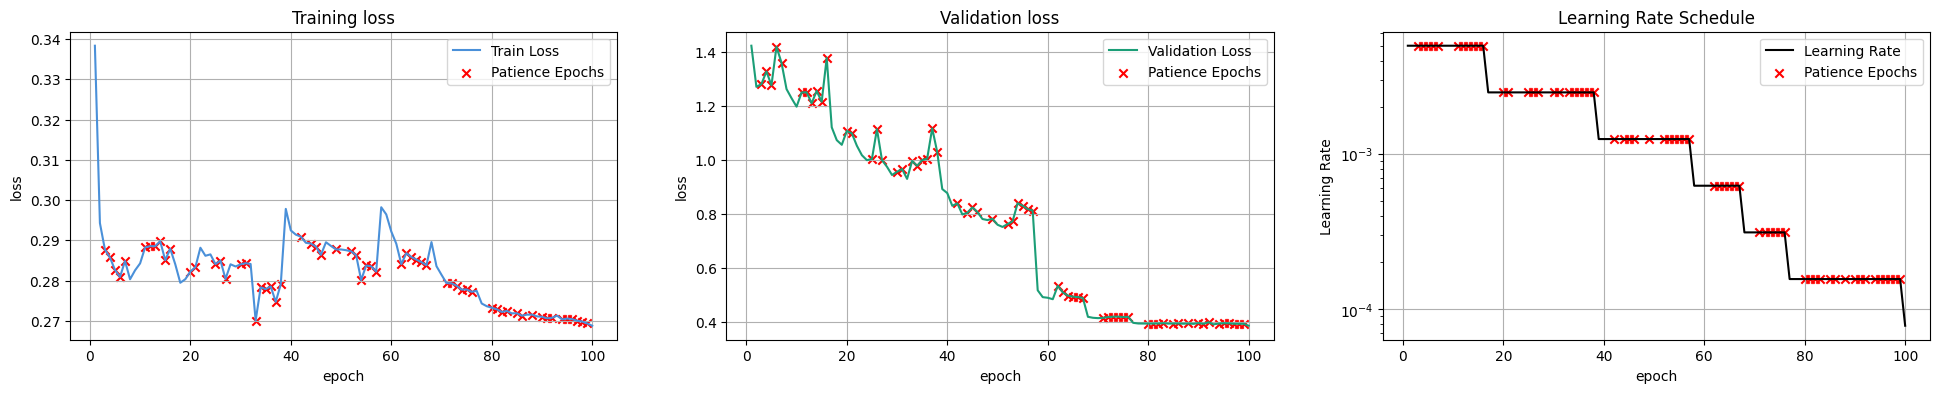

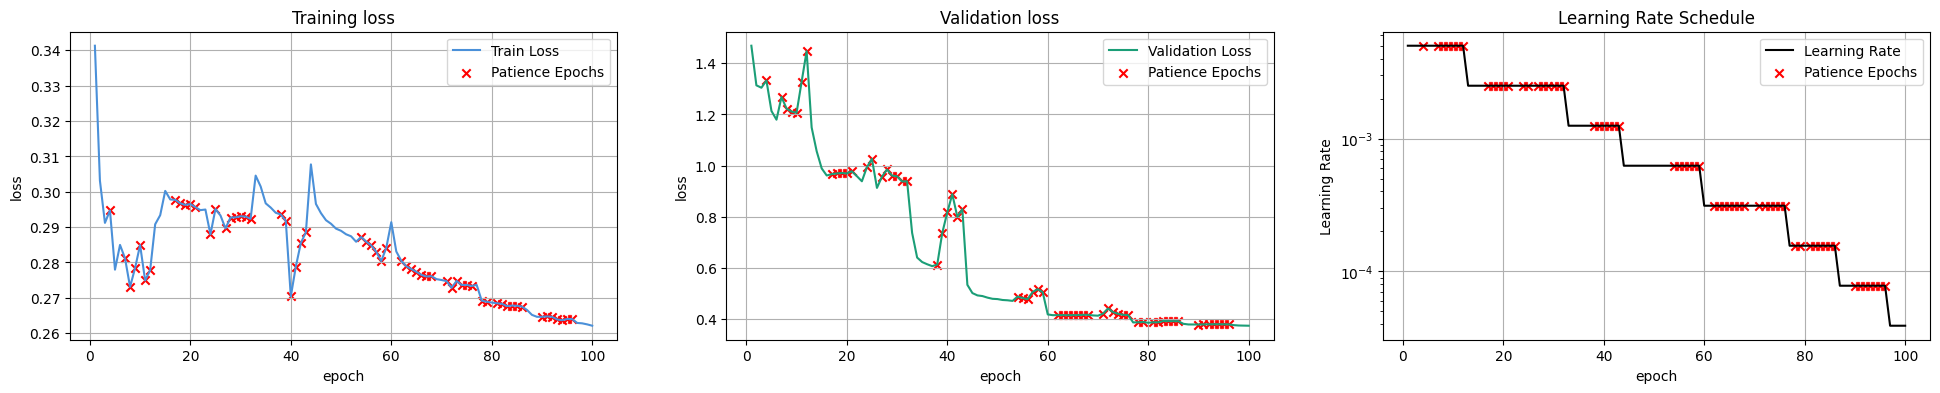

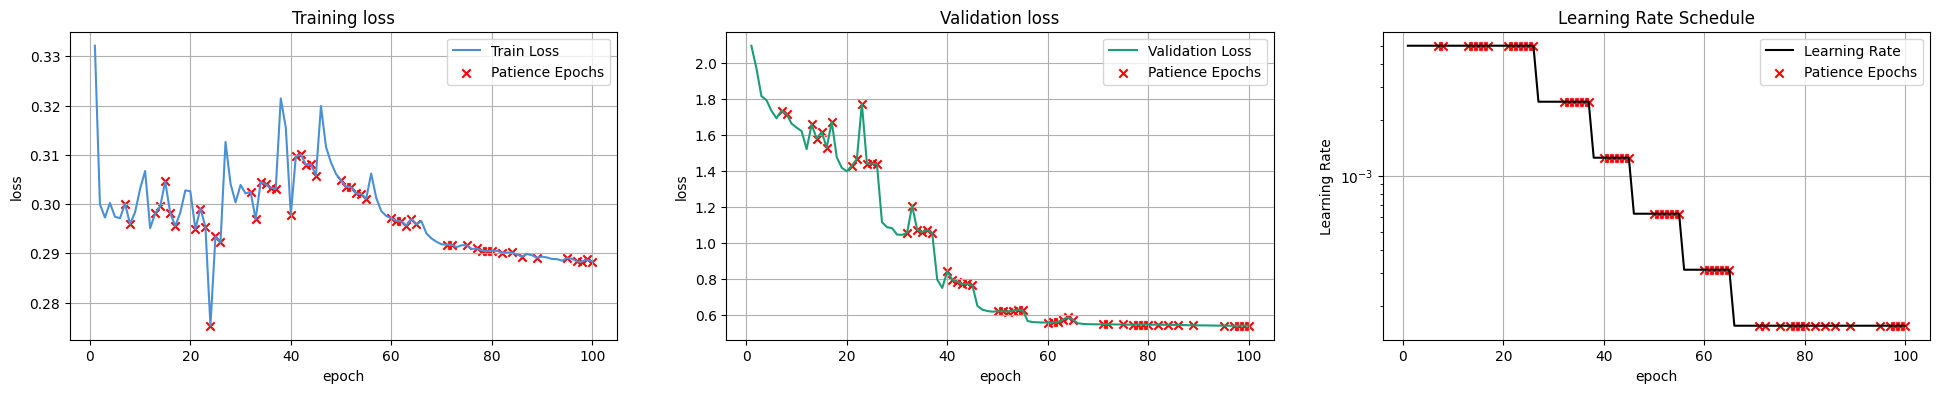

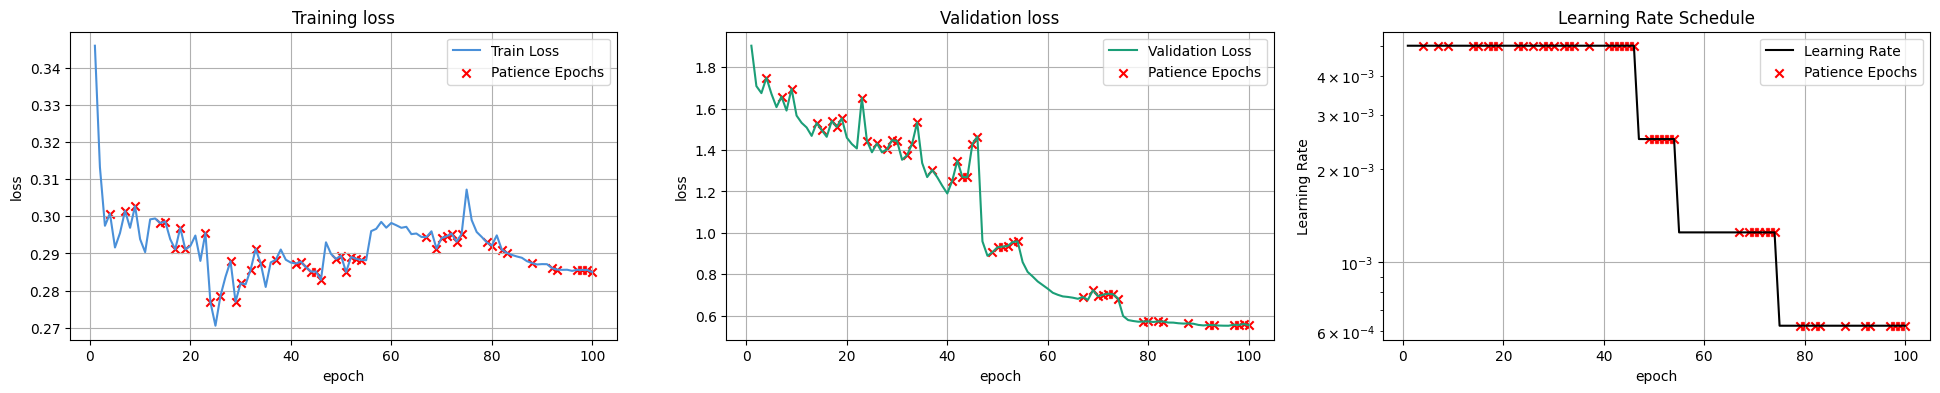

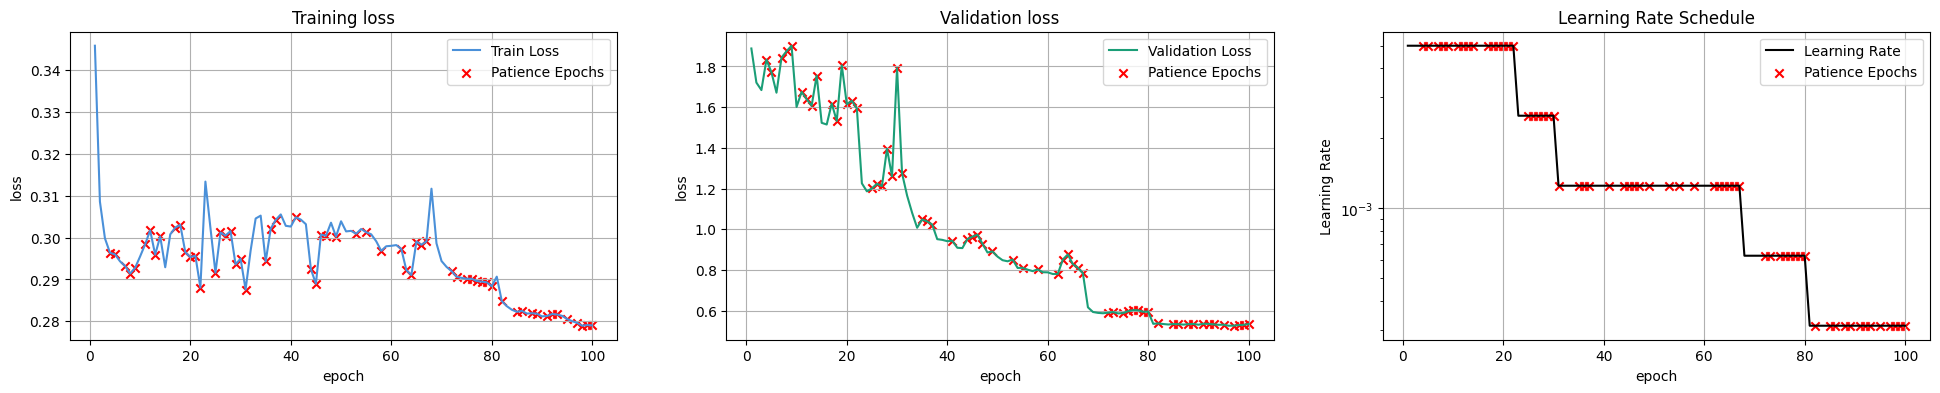

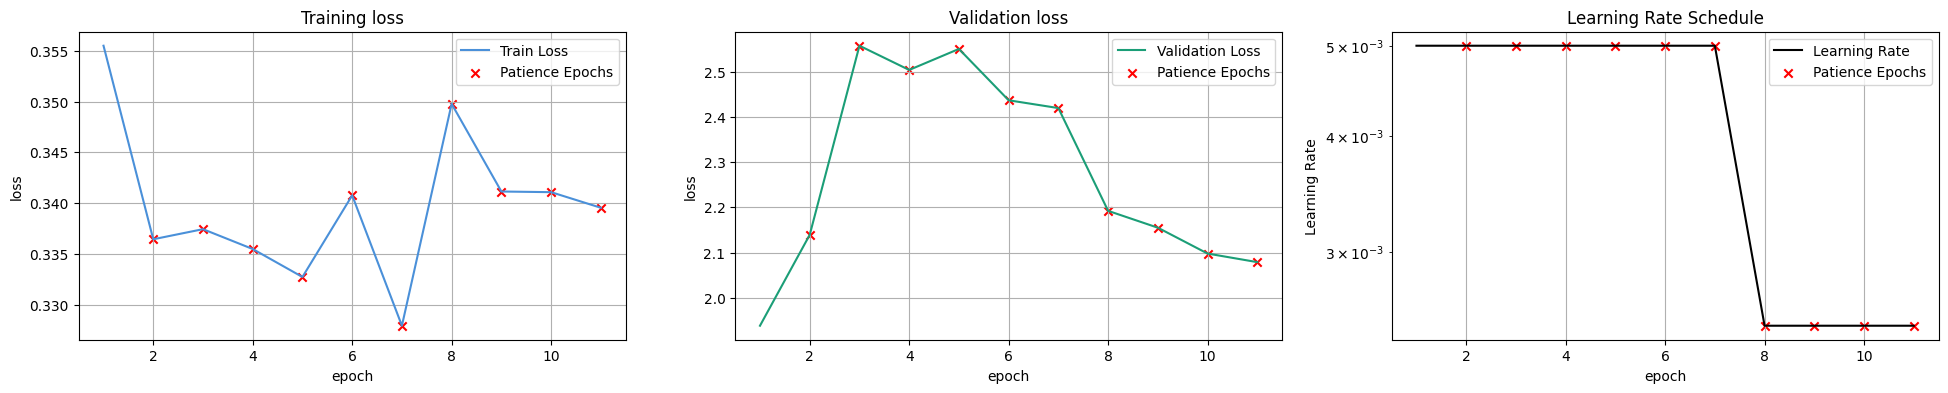

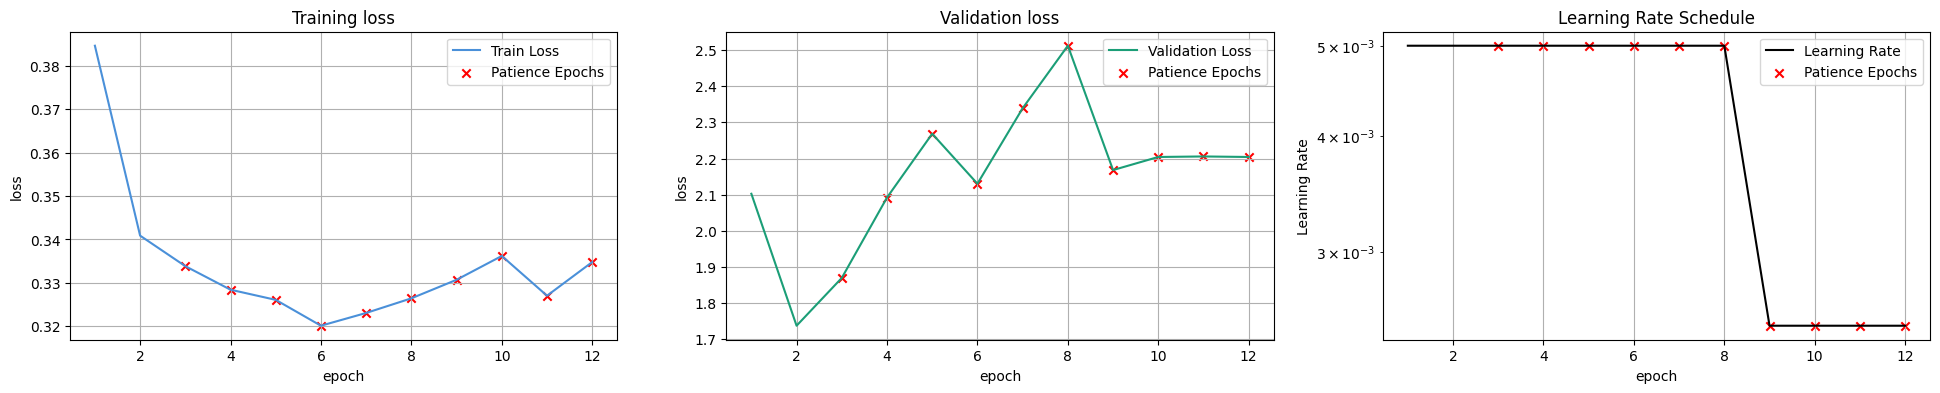

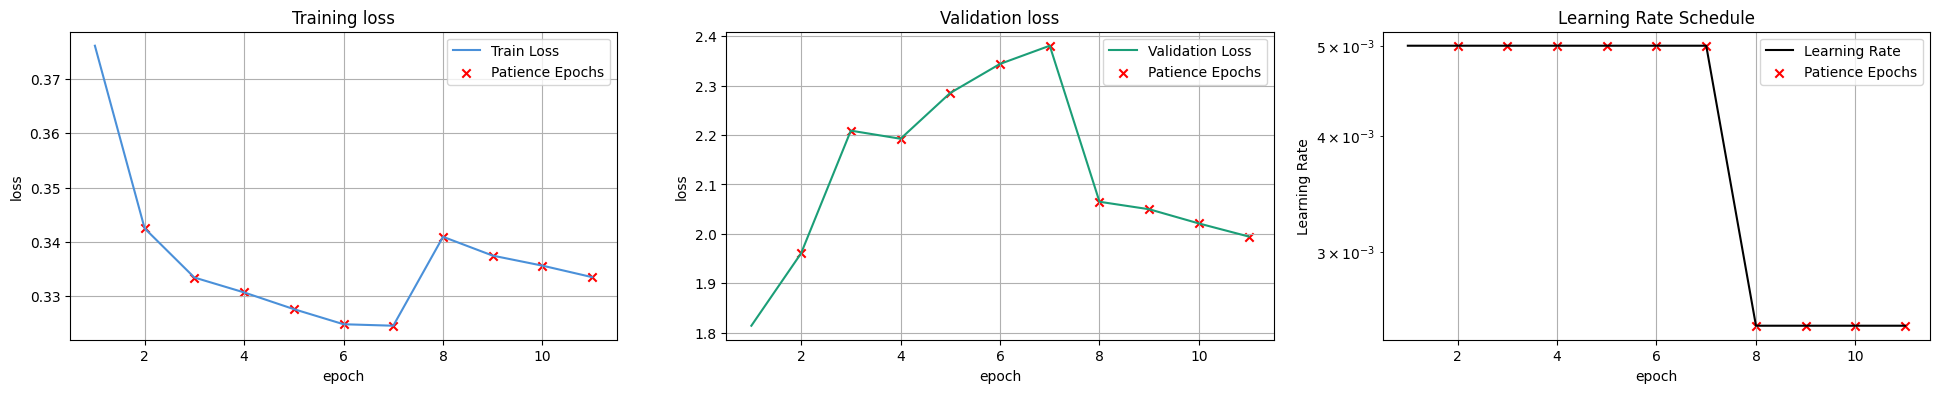

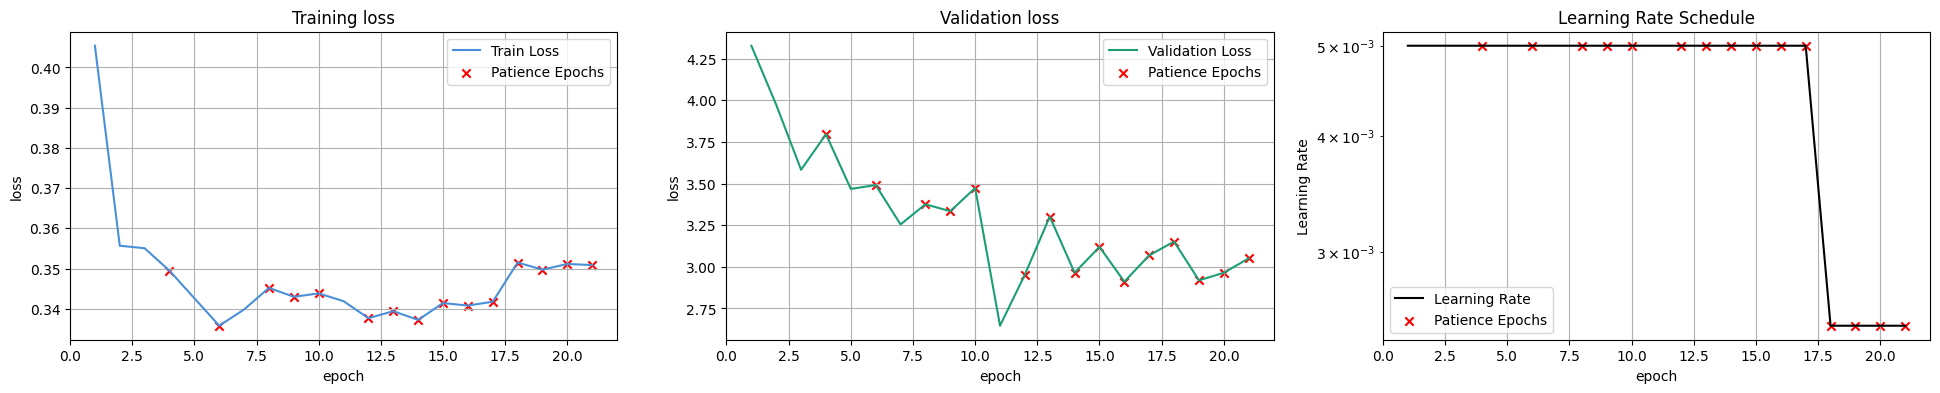

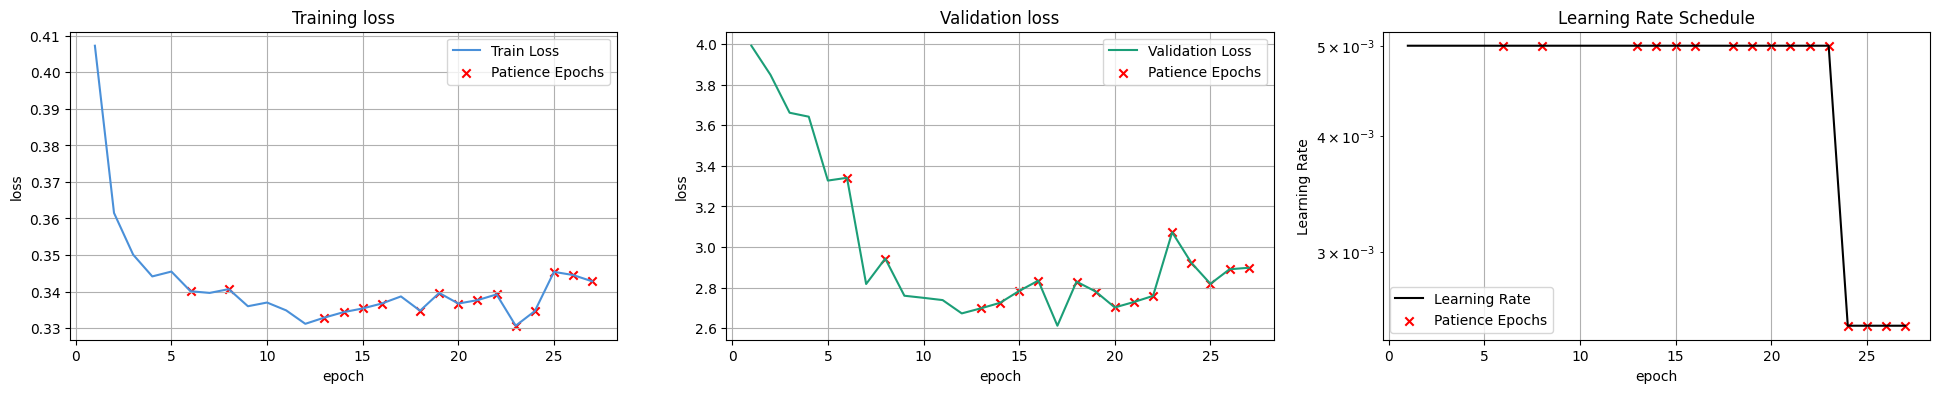

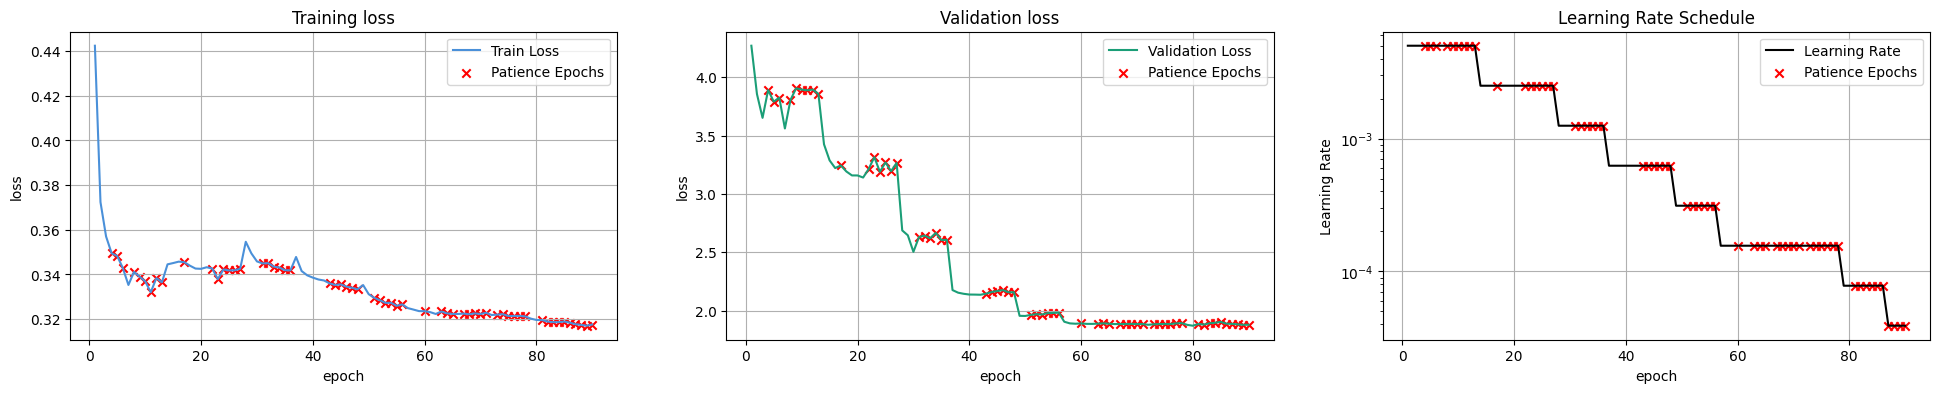

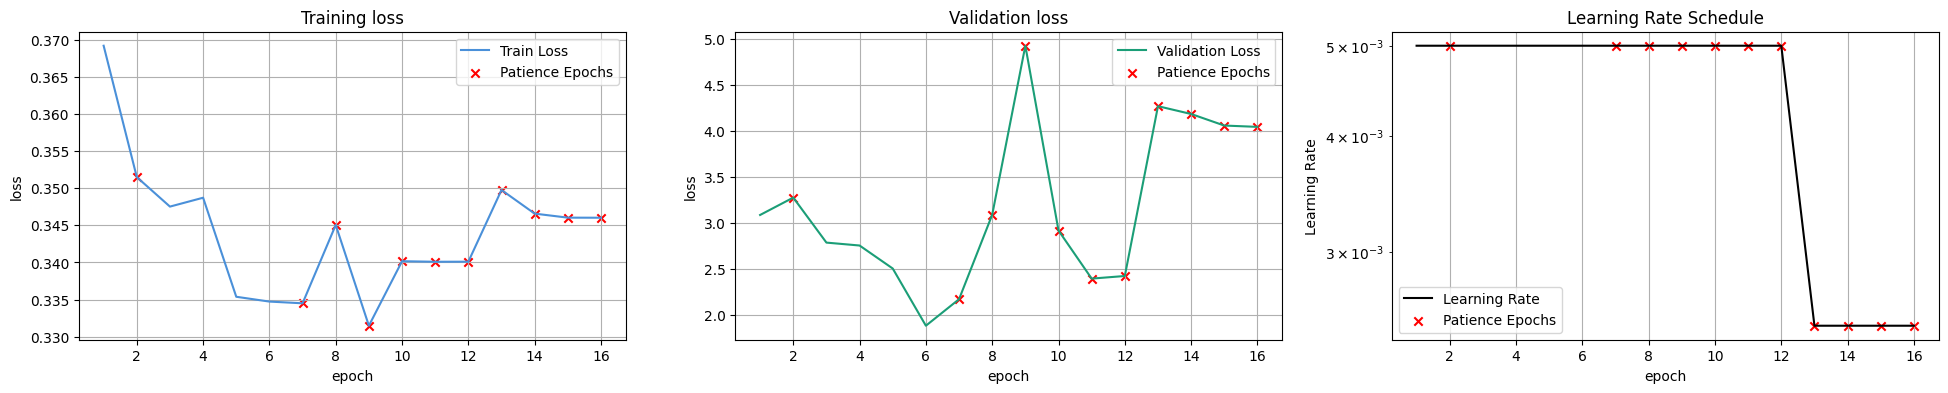

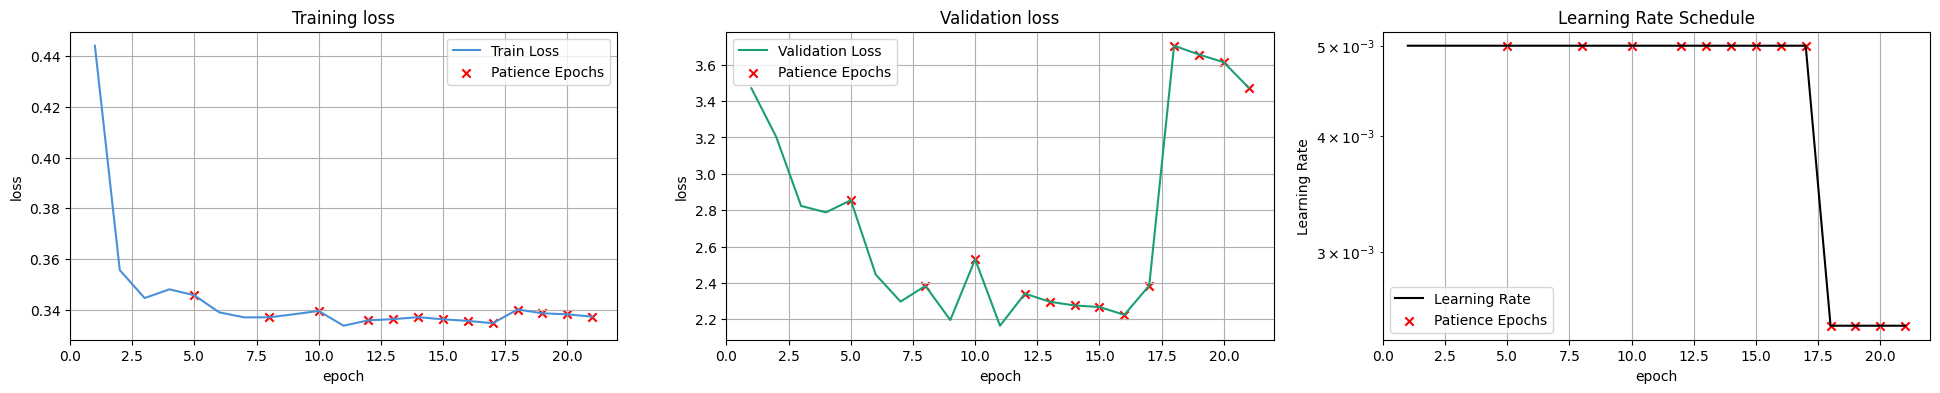

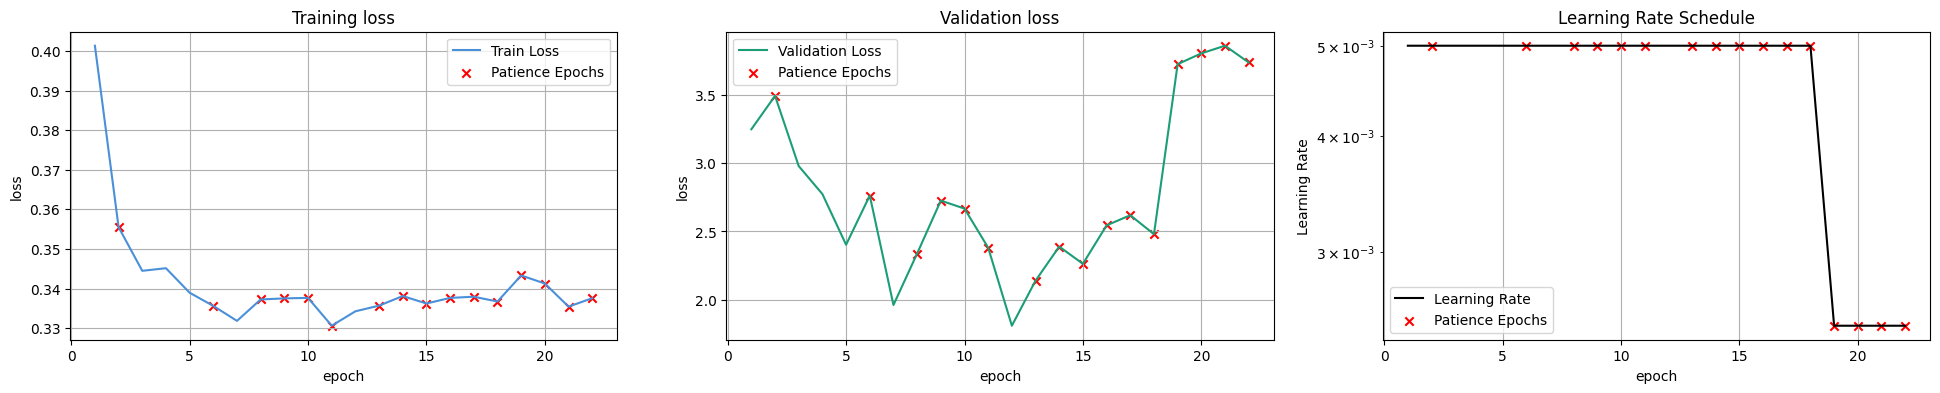

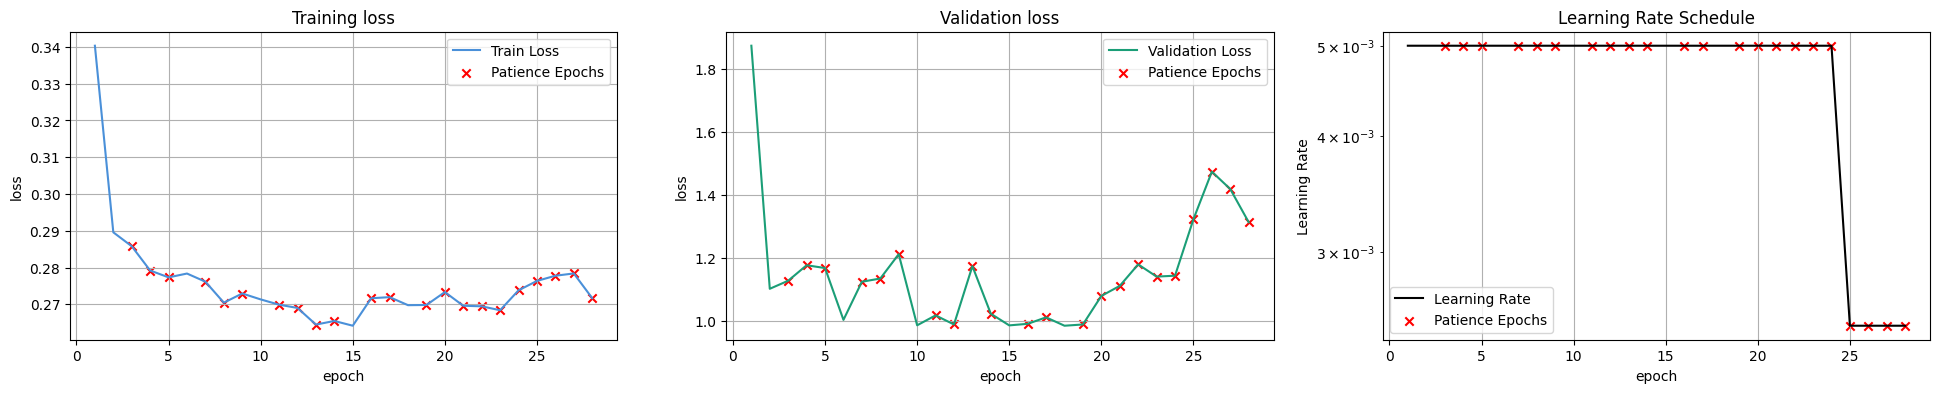

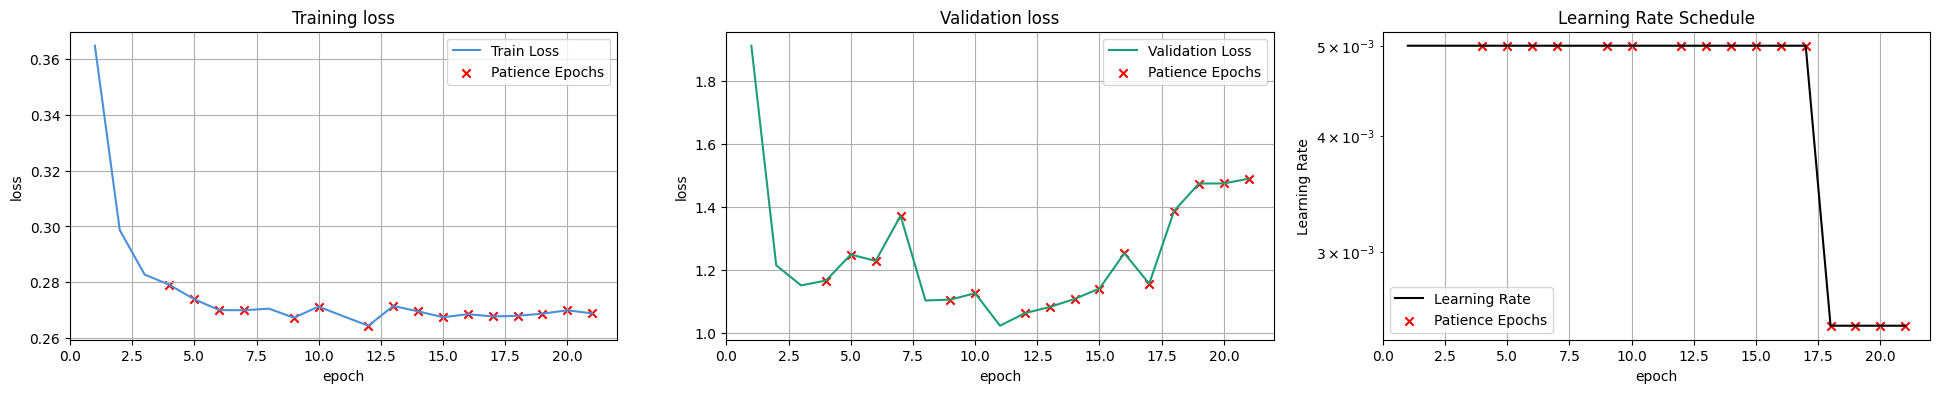

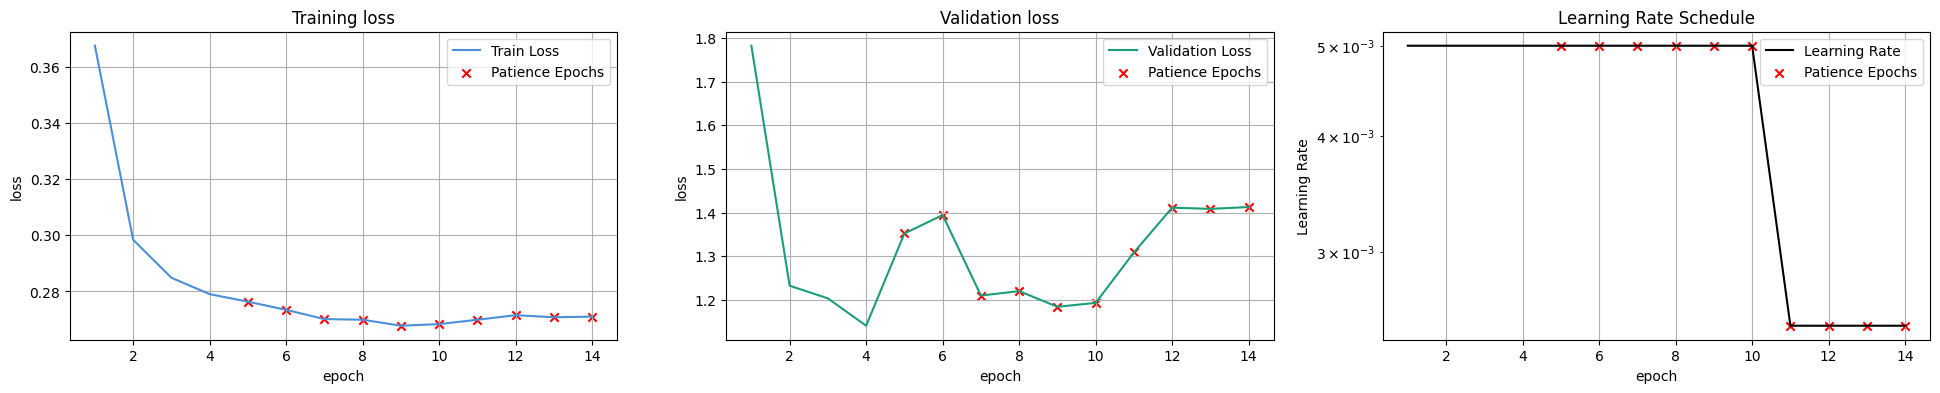

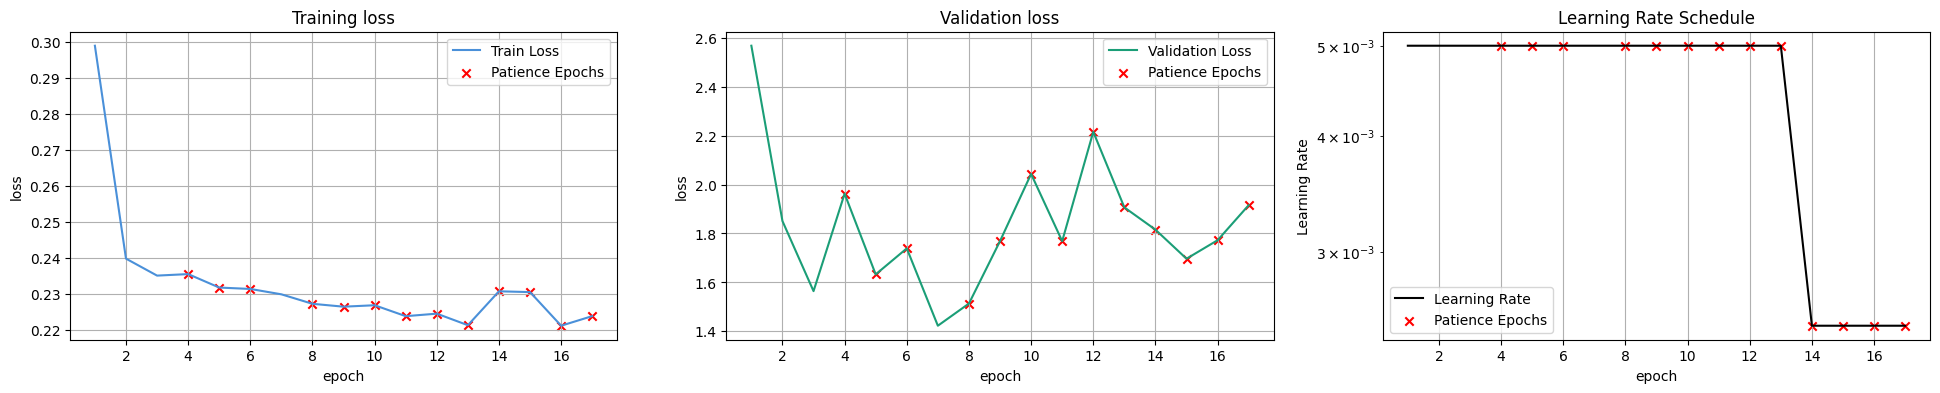

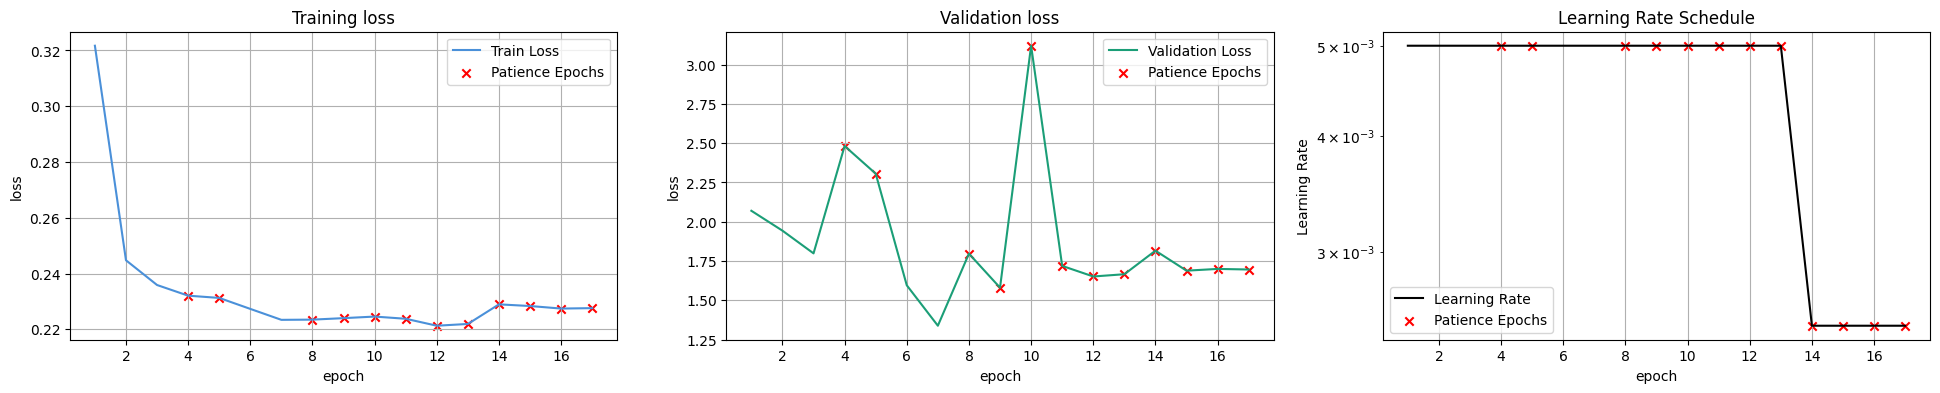

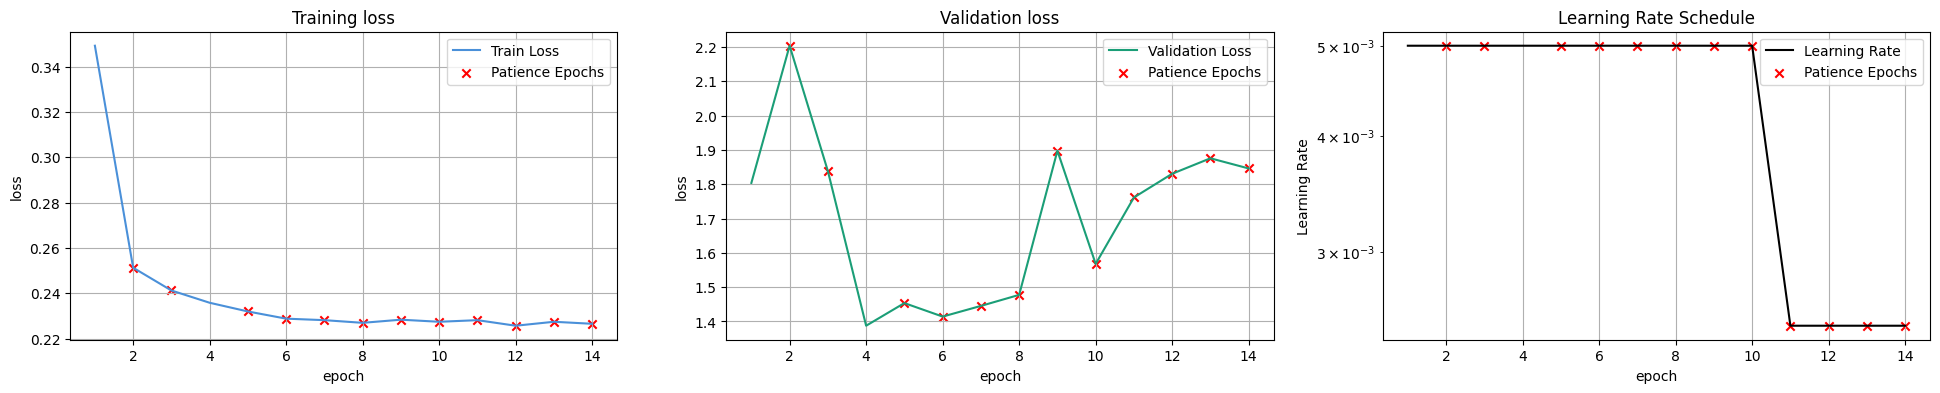

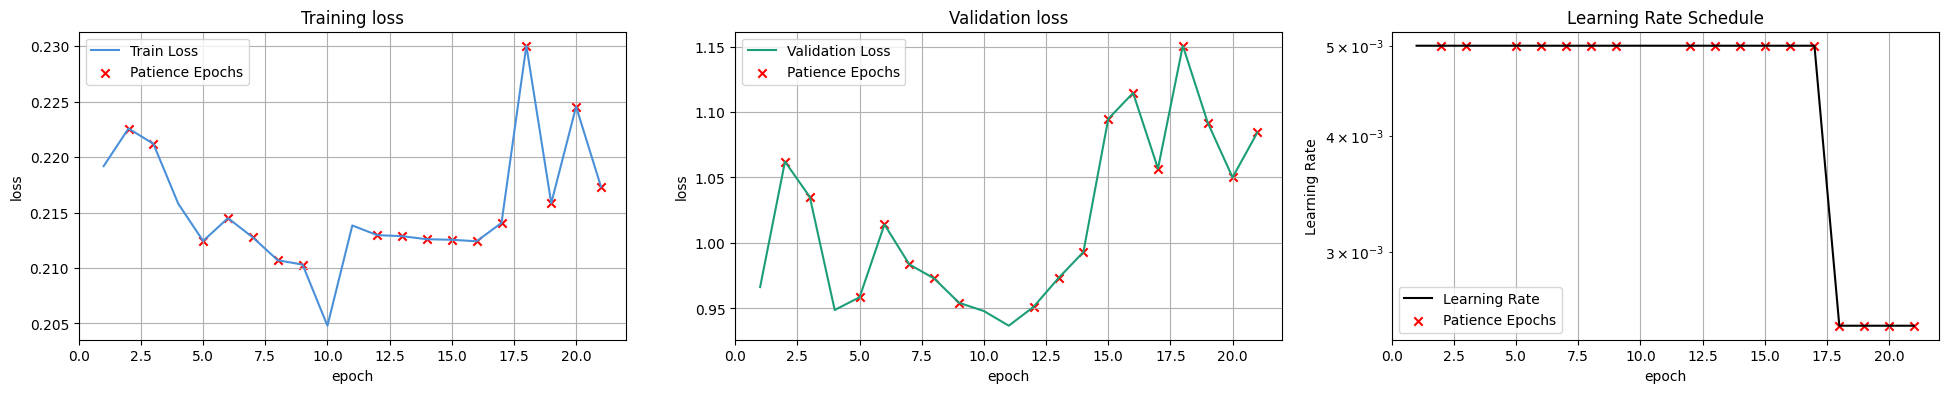

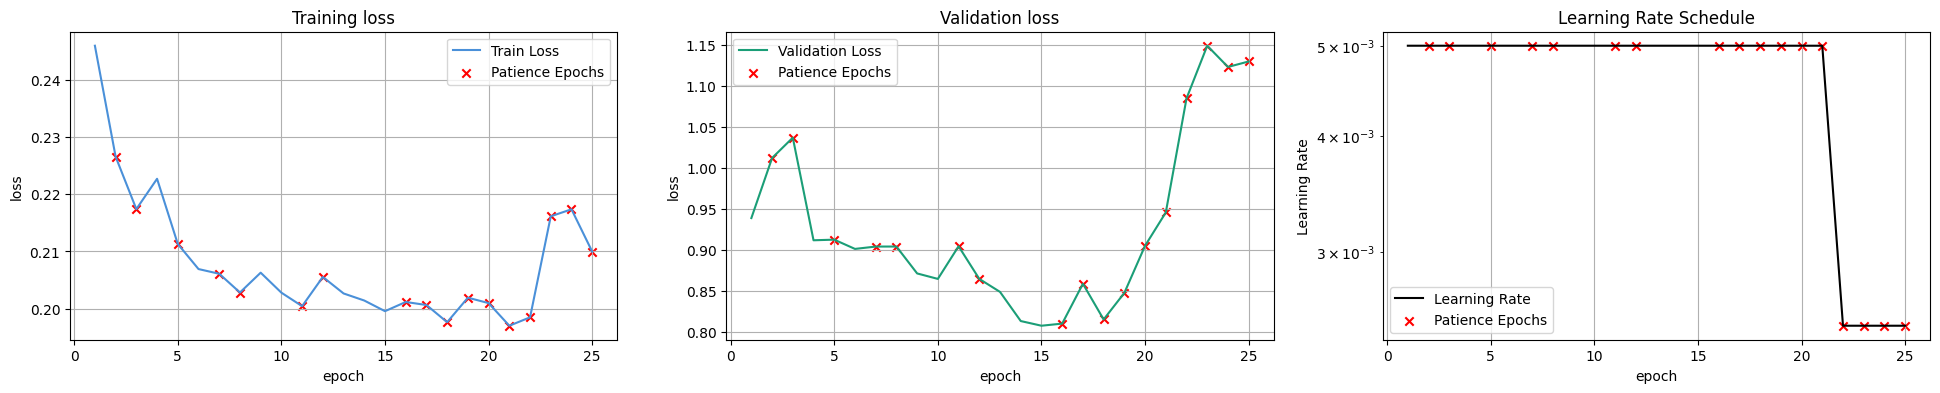

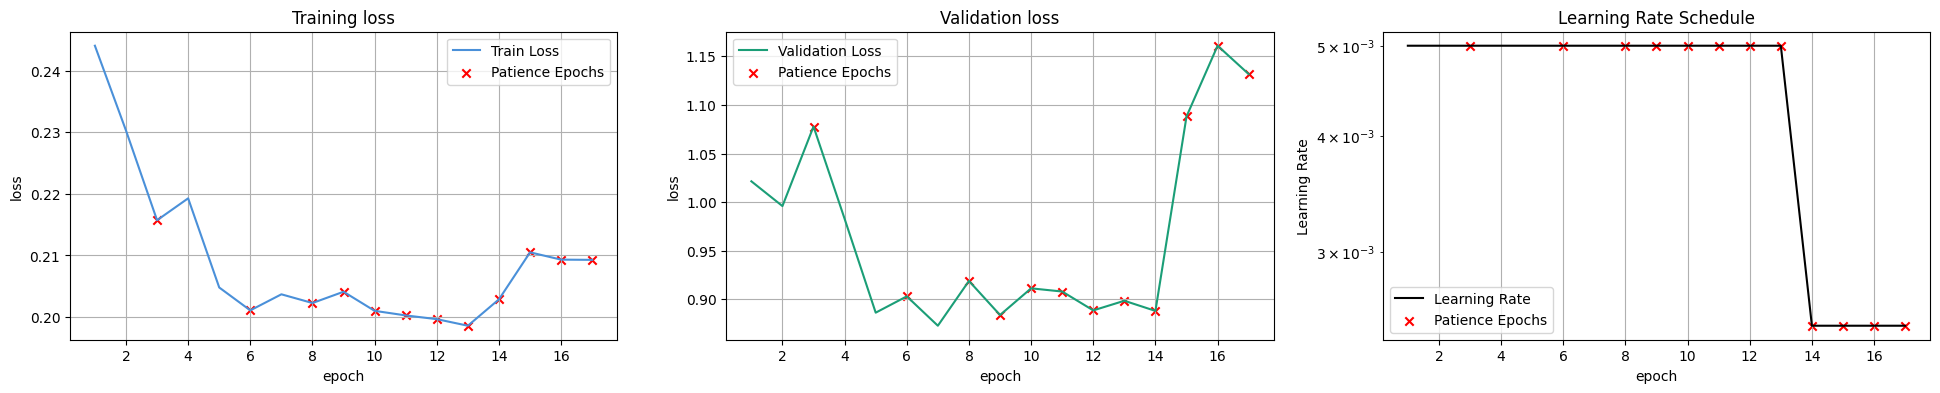

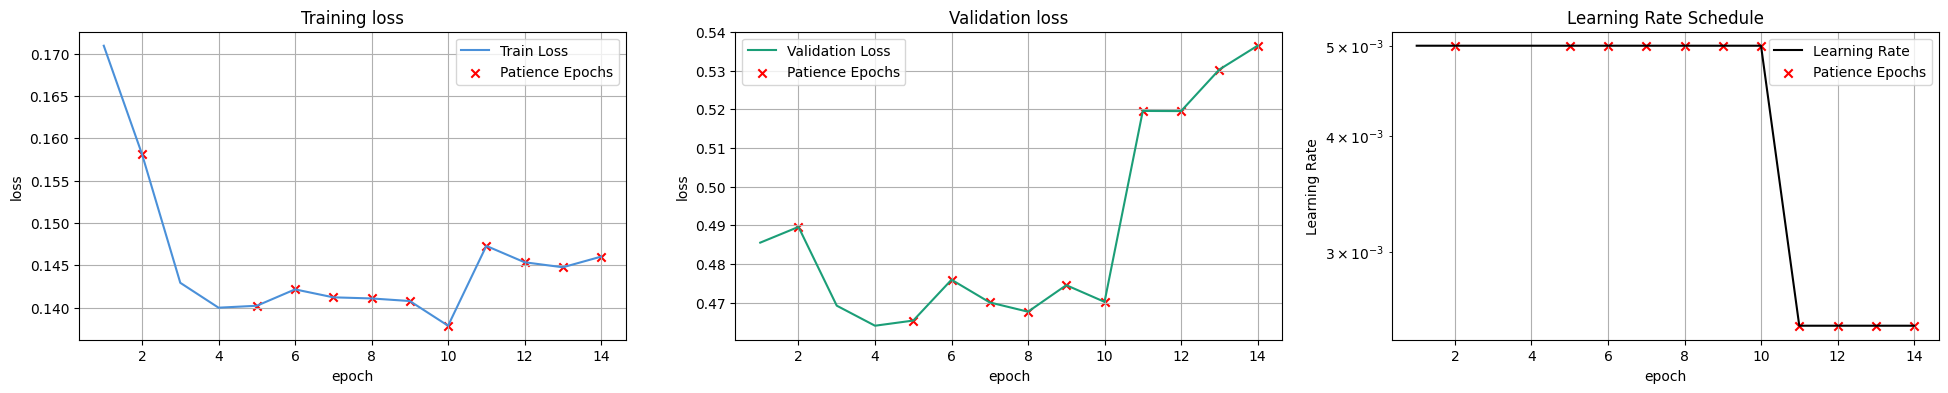

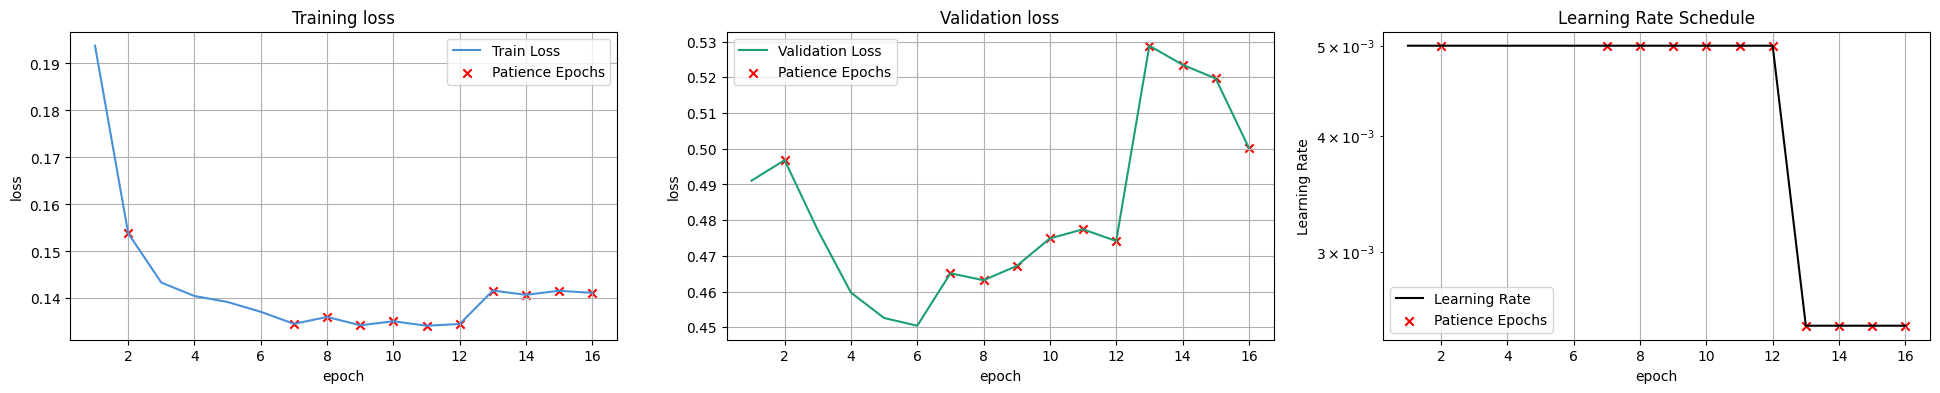

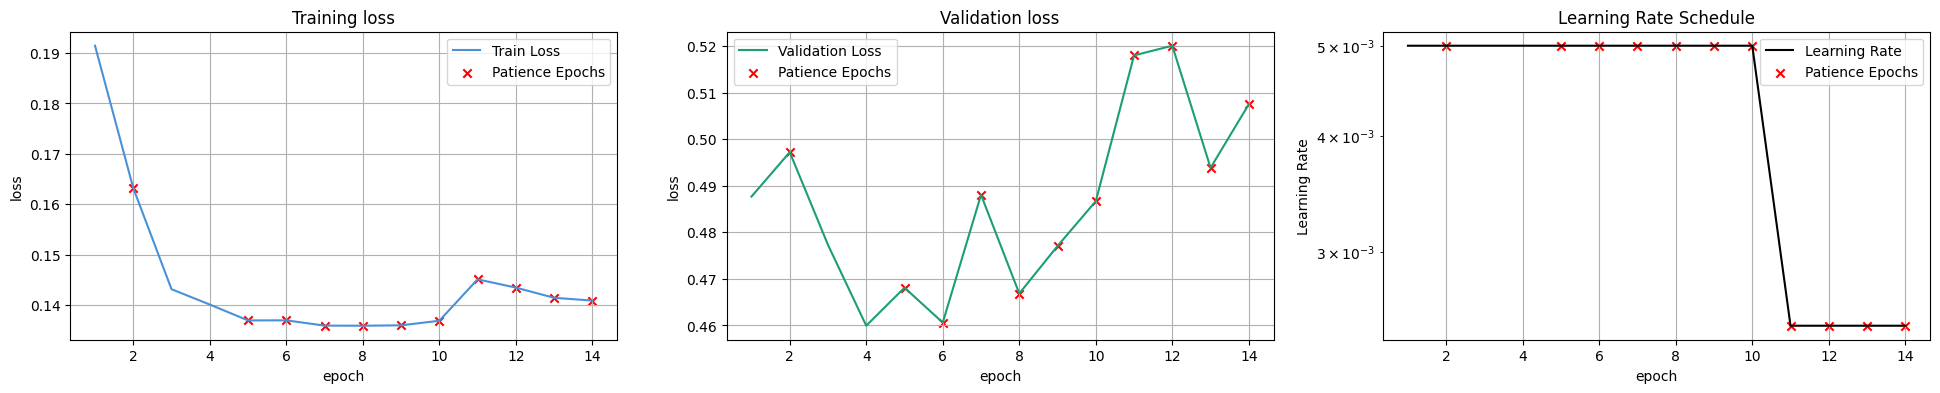

In [61]:
models = {}

n_epochs        = 100
lr              = 0.005
min_delta       = 0.0001
loss            = 'mse'

model_hparams = {
    'hidden_size'     : 64,    # was 128 — halve it
    'gat_hidden_dim'  : 32,    # was 64 — halve it  
    'num_heads'       :2,     # keep
    'temporal_layers' : 1,     # was 2 — single LSTM layer
    'dropout'         : 0.3,   # was 0.2 — slightly more aggressive
}

global_hparams = {
    "lr"                : lr,
    "n_epochs"          : n_epochs,
    "scheduler"         : 'plateau',
    "scheduler_kwargs"  :  {'mode': 'min', 'factor': 0.5, 'patience': 5},
    'min_delta'         : min_delta,
    'loss'              : loss,
    'patience'          : 10,
    }

from src.dataloading.dataloaders import GraphDataLoaderManager
from src.models import GATv2LSTMModel

for fold_idx, fold in enumerate(foldcollection):

    graphdataloader_ig       = GraphDataLoaderManager(fold.foldepidataorchestrator).retrieve_static_graph('identity_graph').build()
    graphdataloader_gn       = GraphDataLoaderManager(fold.foldepidataorchestrator).retrieve_static_graph('geographical_neighbors1').build()
    graphdataloader_cm       = GraphDataLoaderManager(fold.foldepidataorchestrator).retrieve_static_graph('static_commuter24_1').build()    
    
    gatv2_ig = GATv2LSTMModel(graphdataloader_ig, name = f'ig_{fold_idx+1}', verbose = 2)
    gatv2_ig.set_model_hparams(**model_hparams)
    gatv2_ig.set_global_hparams(**global_hparams)
    gatv2_ig.train()
    gatv2_ig.forecast()

    gatv2_gn = GATv2LSTMModel(graphdataloader_gn, name = f'gm_{fold_idx+1}', verbose = 2)
    gatv2_gn.set_model_hparams(**model_hparams)
    gatv2_gn.set_global_hparams(**global_hparams)
    gatv2_gn.train()
    gatv2_gn.forecast()

    gatv2_cm = GATv2LSTMModel(graphdataloader_cm, name = f'cm_{fold_idx+1}', verbose = 2)
    gatv2_cm.set_model_hparams(**model_hparams)
    gatv2_cm.set_global_hparams(**global_hparams)
    gatv2_cm.train()
    gatv2_cm.forecast()

    models_fold = [gatv2_ig,gatv2_gn,gatv2_cm]
    models[f'fold{fold_idx+1}'] = models_fold

In [62]:
# model_evaluations_foldwise 
from src.evaluation import Evaluator

igs    = []
gns  = []
cms = []


for fold_idx, fold in enumerate(foldcollection):

    igs.append(models[f'fold{fold_idx + 1}'][0])
    gns.append(models[f'fold{fold_idx + 1}'][1])
    cms.append(models[f'fold{fold_idx + 1}'][2])    

evaluators = {
    'identity graphs':  Evaluator(igs).add_evaluation(),
    'geometric graphs': Evaluator(gns).add_evaluation(),
    'commuter graphs':  Evaluator(cms).add_evaluation()
}

figure_raw1 = (evaluators['identity graphs'].plotter.plot_metric_compilation(metrics = ['ccc','r2','mape','smape'])
            .change_figsize(14,5)
            .layout.set_ylim([-1,1], ax = 1)
            .labels.change_suptitle(f'identity graphs', fontweight='bold', fontsize=14)
            )



figure_raw2 = (evaluators['geometric graphs'].plotter.plot_metric_compilation(metrics = ['ccc','r2','mape','smape'])
            .change_figsize(14,5)
            .layout.set_ylim([-1,1], ax = 1)
            .labels.change_suptitle(f'geometric', fontweight='bold', fontsize=14)
            )


figure_raw3 = (evaluators['commuter graphs'].plotter.plot_metric_compilation(metrics = ['ccc','r2','mape','smape'])
            .change_figsize(14,5)
            .layout.set_ylim([-1,1], ax = 1)
            .labels.change_suptitle(f'commuter', fontweight='bold', fontsize=14)
            )


computing metrics: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 9/9 [00:13<00:00,  1.54s/it]
/scratch/de-schrijvers/projects/infectious_disease_gnn/src/evaluation/evaluationplotter.py:215: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='center', fontsize=8)
/scratch/de-schrijvers/projects/infectious_disease_gnn/src/evaluation/evaluationplotter.py:215: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='center', fontsize=8)
/scratch/de-schrijvers/projects/infectious_disease_gnn/src/evaluation/evaluationplotter.py:215: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. af

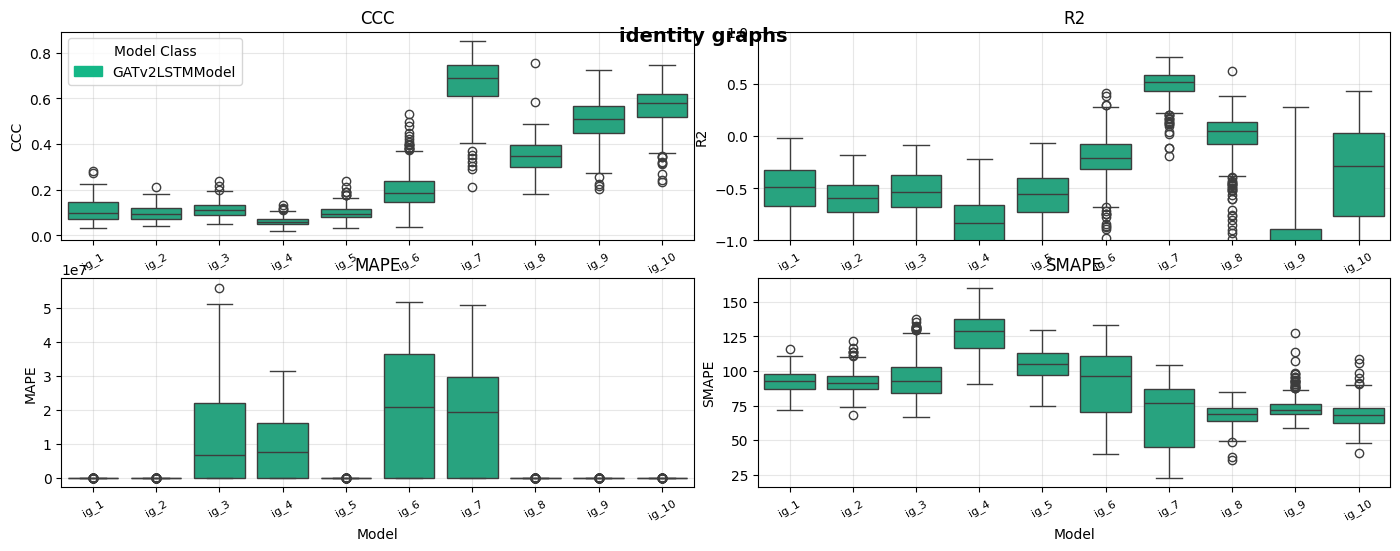

In [63]:
figure_raw1.show()

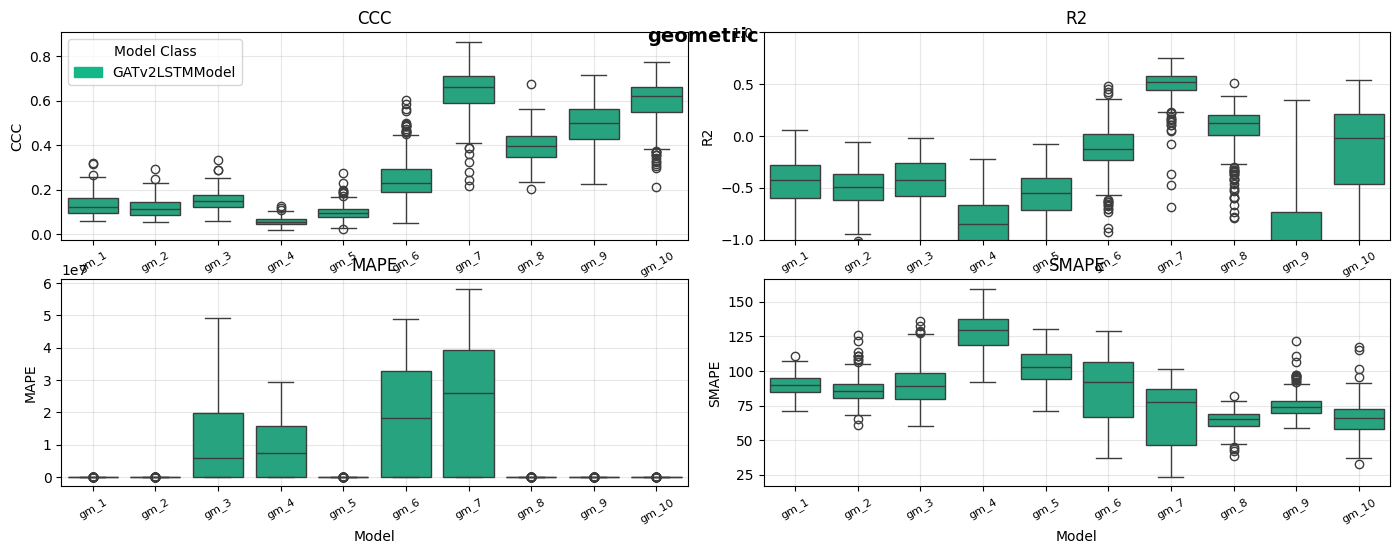

In [64]:
figure_raw2.show()

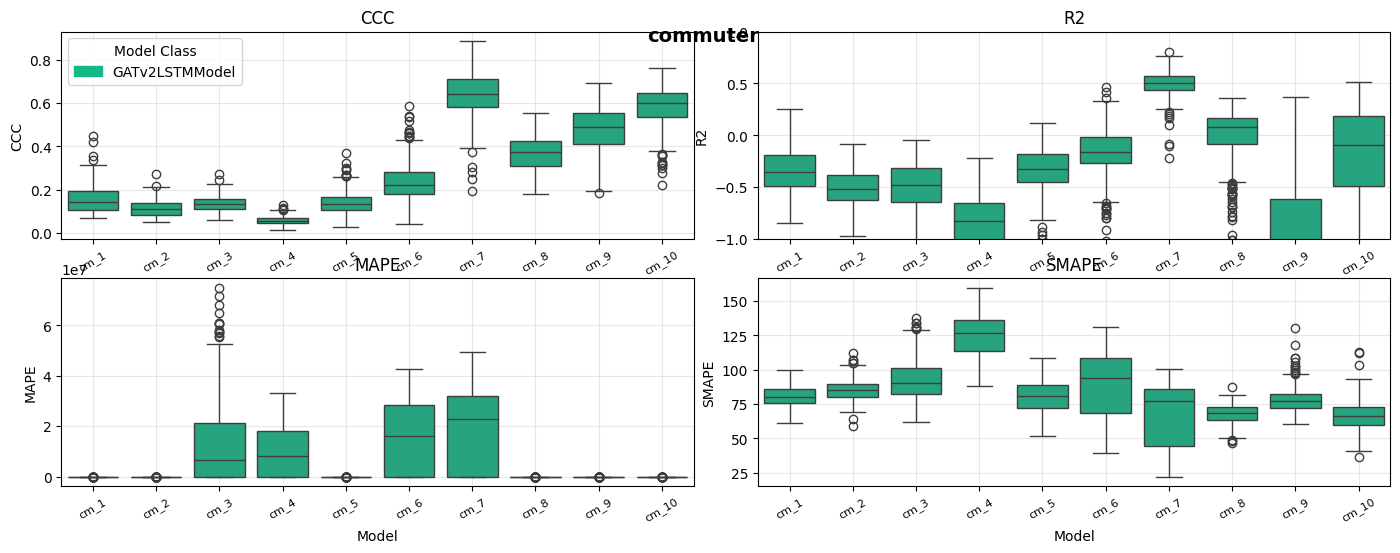

In [65]:
figure_raw3.show()

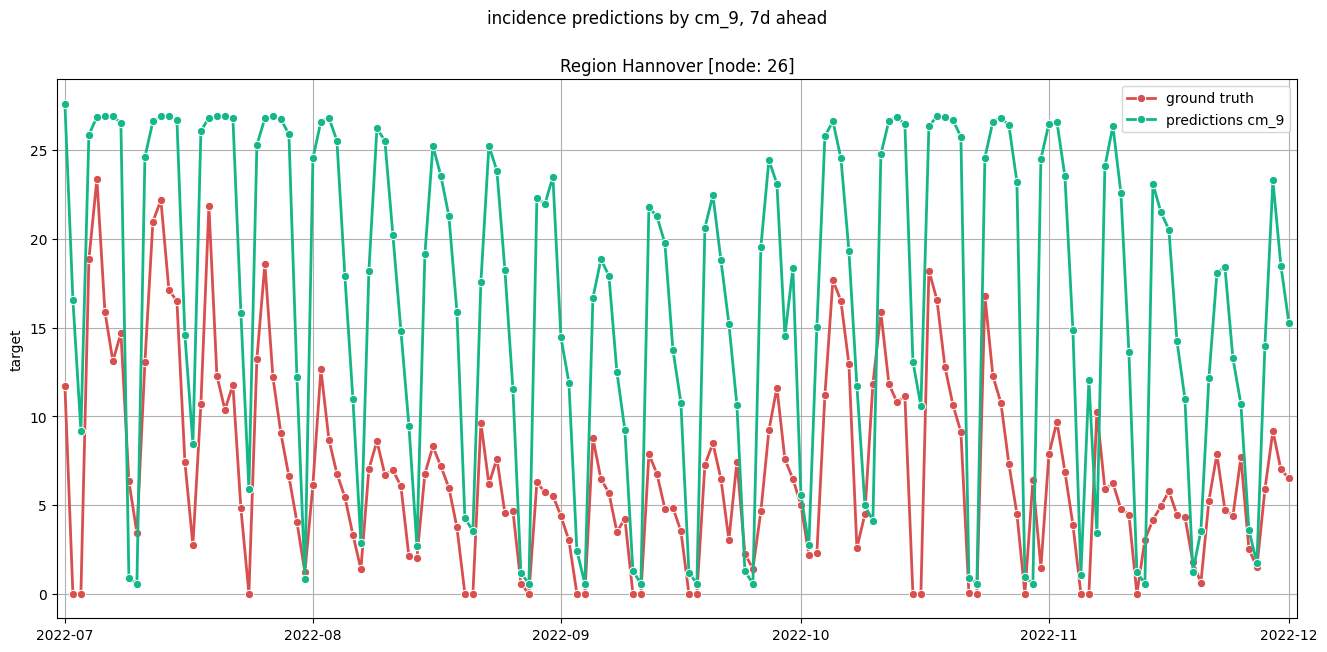

In [73]:
cms[8].show_forecasts(26).show()

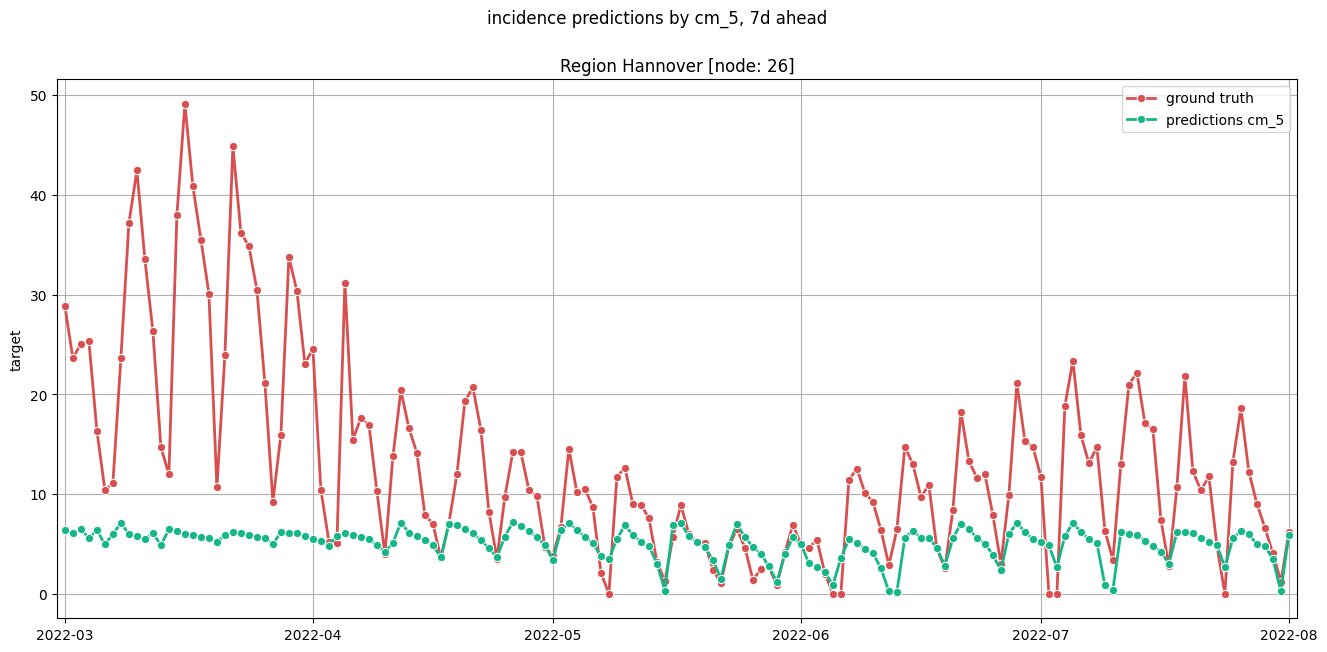

In [74]:
cms[4].show_forecasts(26).show()

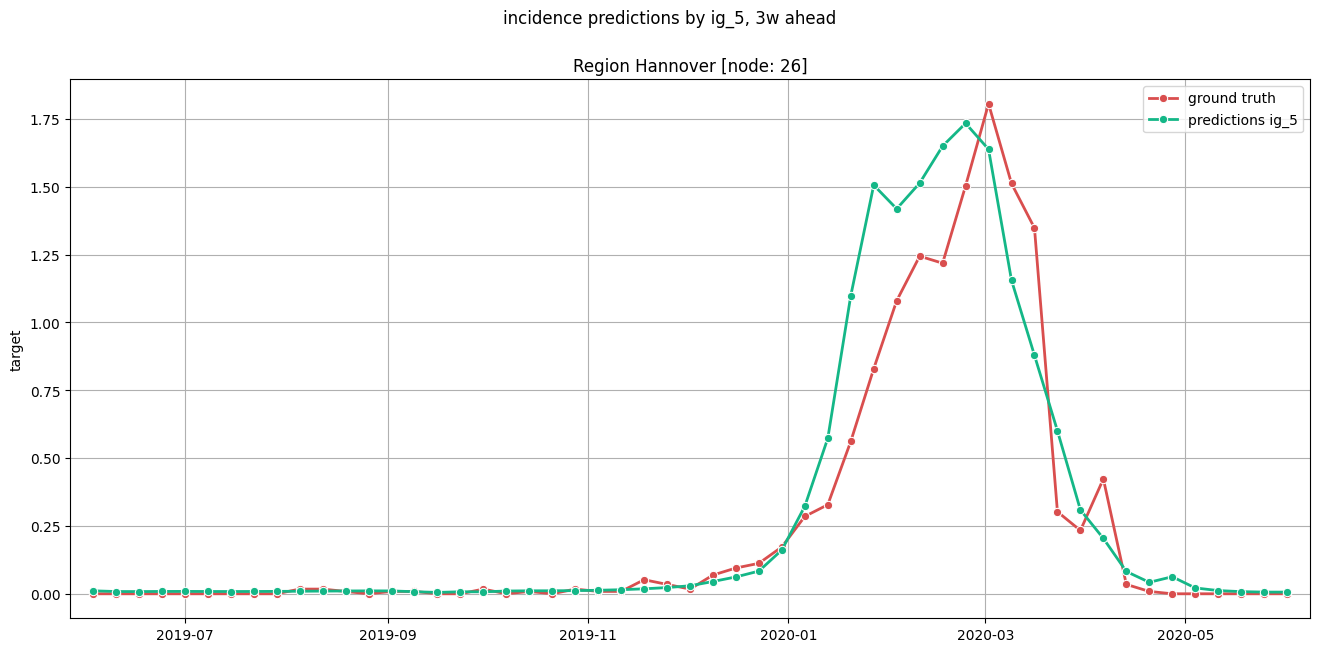

In [25]:
igs[4].show_forecasts(26).show()